In [1]:
import sys, io, re, gc, time, contextlib
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from scipy import ndimage
import dolfyn                                          # dolfyn 1.3.0, dolf_env kernel
from dolfyn.adp import clean as aclean
from dolfyn.rotate.api import rotate2, set_declination, calc_principal_heading

# ADCP QC (Signature 1000)
Same steps as `adv_QC.ipynb`, in the same order:
1. clock drift correction (whole raw record, before anything else)
2. trim to in-water start/end, atmospheric pressure correction, configured salinity (sound speed)
3. beam quality: correlation gate 0.3 + 0.4 sqrt(fs/25) and SNR < 8 dB flag (Elgar et al. 2001, 2005), surface side lobes
4. Elgar replacement of low-correlation samples (runs <= 1 s linear, longer = 1-s running mean); no despiking
5. rotation to earth / shore-normal (internal compass + declination)
6. z² test (Elgar et al. 2005, §3.3): measured vs velocity-predicted pressure variance, 0.05-0.20 Hz, per hour
   and cell; hours outside 0.5 < z² < 2.0 fail `seg_ok`
7. clock check against the co-located VC10 (new: the seconds-level check `adv_QC` left pending)
8. final product: one 4 Hz file for the whole deployment

**What differs from the Vectors, and why**
- *Size.* 4 Hz × 23 cells × 5 beams for 57 days: `vel` alone is ~7 GB as float32. This Mac has 8 GB RAM
  and ~20 GB free disk, so nothing is held for the whole record and no per-step copies are saved.
  Sections 1–7 run on a **test window** (the VC5 equivalent) held in memory. Section 8 runs the same
  functions day by day and appends to one 4 Hz file, `data/processed/qc/ADCP_qc.nc`.
- *Reading.* `dolfyn.read` fails on this file as it stands (two corrupt records). `processing/ad2cp_reader.py`
  patches the reader; its docstring explains the patch.
- *Pressure.* The Signature subtracts a fixed offset (`POFF`, from the deployment log) and clips at 0, so in air
  it reads exactly 0. The Vector's in-air offset method can't be used; `POFF` is added back instead.
- *Beam gate.* The same Elgar et al. (2001, 2005) rule as the Vectors, 0.3 + 0.4·√(fs/25) = **46.0 % at 4 Hz**
  (dolfyn reports `nominal_corr` = 67 % for this setup). Caveat: Elgar's √fs scaling assumes more pings are
  averaged into each slower sample, which holds for the Vector (100-250 Hz internal pinging) but is not
  established for the Signature's 4 Hz burst. Each beam and cell is gated on its own. Cells near the surface are
  also masked for side-lobe contamination (dolfyn `find_surface_from_P` / `nan_beyond_surface`); those are never
  replaced.
- *Replacement.* As the Vectors (Elgar et al. 2001, 2005), per beam and cell in beam coordinates before rotation:
  low-correlation runs ≤ 1 s are linearly interpolated, longer runs get a 1-s running mean of the recorded values.
  No despiking (removed 2026-10-03 to match `adv_QC`).
- *Rotation.* Unlike the cable-head Vectors, the Signature's compass and tilt sensor sit in the same housing as
  the transducers, so the internal heading/pitch/roll do describe the beams. dolfyn `rotate2` is used as intended.

### 0. Parameters
Sections 1–7 run on `TEST_WINDOWS`: the calmest day at the co-located VC10 and the largest-wave days
(09-08, Hs_SS ≈ 3 m at VC10, from `VC10_QC.nc`). The pitch/roll step on 09-06 → 09-08 also falls in that window.
Once the test window checks out, set `RUN_FULL = True` in section 8.

In [2]:
##-----sensor-----##
sensor_id = "ADCP"   # row in sensor_notes.csv: Signature 1000 S/N 103043, transect C, ~3 m W of VC10
raw_dir   = Path("/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/raw/Signature1000/S103043A007_HNL_10m")
RAW_FILE  = raw_dir / "S103043A007_HNL_10m.ad2cp"
LOG_FILE  = raw_dir / "Deployment_103043_2026-09-20-23-51-16.log"
# Config (S103043A007_HNL_10m.deploy): burst only, 4 Hz, 14400 samples every 3600 s (continuous), 5 beams,
# 23 cells x 0.5 m, blanking 0.1 m, beam coordinates, salinity 35, sound speed measured, AST + altimeter on.
S_CFG = 35.0          # PSU, salinity the instrument used for its sound speed (SETPLAN ... SA=35)

##-----test window (sections 1-7)-----##
TEST_WINDOWS = [("2026-08-21 00:00", "2026-08-22 00:00"),   # calmest day at VC10 (daily Hs_SS 0.69 m)
                ("2026-09-07 12:00", "2026-09-09 12:00")]   # largest waves (09-08 Hs_SS 2.96 m); pitch/roll step
CHUNK_H = 24          # h of data per chunk in the full run (section 8); ~0.3 GB of RAM per 24 h
KEEP_RANGE_MAX = 9.6  # m from the transducer. Cells above this are ALWAYS inside the side-lobe zone: the highest
                      # deployed pressure in the coarse scan is 11.16 dbar (~11.1 m of water above the transducer),
                      # so the limit never exceeds 11.1 * cos(25) - 0.5 = 9.6 m. Section 3 prints the proof.
DROP_VARS = ["mag", "accel", "mag_b5", "accel_b5"]  # magnetometer/accelerometer raw vectors (heading/pitch/roll kept)

# section 1: clock drift
DRIFT_OVERRIDE = -5.062   # s, + = sensor clock fast. None = sensor_notes.csv ("-6").
                          # Set 2026-09-28 at the user's request: with -6 s, the wave-band p-p lag against the
                          # co-located VC10 grew linearly from +0.04 to +0.89 s over the record (section 7b;
                          # slope +0.938 s per record length, residual std 0.022 s), so -6 + 0.938 = -5.062 s.
                          # The CSV value is the only whole number in the drift column. Assumes VC10's +3.571 s is right.

# section 2: trim + pressure + sound speed
P_WET        = 3.0    # dbar. In air the Signature reads exactly 0 (POFF subtracted, clipped); deployed ~10.4
BUFFER_S     = 10     # s taken off each end of the window, after the handling edges
HEAD_STD_MAX = 0.25   # deg. Floor of the handling threshold on the 1-min circular heading std (as adv_QC)
HEAD_STD_K   = 3.0    # threshold = max(HEAD_STD_MAX, HEAD_STD_K * median 1-min std on the test window)
CALM_MIN_MIN = 30     # min. A calm stretch must last this long to count as "deployed"
COARSE_STEP_MIN = 30  # min between positions of the coarse whole-record scan (cached after the first run)
COARSE_NPING    = 40  # pings averaged at each position (10 s)
S_TRUE       = 35.0   # PSU, ASSUMED ambient salinity (as adv_QC). Equal to S_CFG, so the sound-speed factor is 1
RHO, GRAV    = 1023.0, 9.79   # kg/m3, m/s2 (21 N): dbar -> m of water

# section 3: beam quality (Elgar, Raubenheimer & Guza 2001 JTECH 18; 2005 MST 16, lit/), as adv_QC
H_DEPLOY        = 0.5    # m, transducer face above the bed. Estimate ("approx. 50 cm", field team)
CORR_A, CORR_B  = 0.30, 0.40   # min beam correlation = CORR_A + CORR_B * sqrt(fs / CORR_REF_FS), as a fraction:
CORR_REF_FS     = 25.0         # SonTek's 0.7 at 25 Hz relaxed as sqrt(fs). 46.0 % at 4 Hz; computed in section 3
SURFACE_SOURCE  = "min"  # surface for the side-lobe mask: "pressure" = dolfyn find_surface_from_P;
                         # "ast" = H_DEPLOY + AST distance; "min" = the lower of the two, per ping (conservative:
                         # pressure is attenuated under wave troughs, so alone it puts the trough surface too high)
AST_RANGE       = (1.0, 15.0)  # m. AST distances outside this are treated as missing
SNR_MIN         = 8.0    # dB above the in-air noise floor (Elgar et al. 2005 value for Vectors, as adv_QC)
SNR_RUN_FRAC    = 0.0081 # Elgar et al. 2005: an hour fails seg_snr_ok if > 0.81 % of samples are low SNR (flag only)
APPLY_SNR       = False  # True also treats low-SNR samples as bad (replaced in section 4)

# section 4: Elgar replacement of low-correlation samples (no despiking, as adv_QC)
ELGAR_INTERP_MAX_S = 1.0  # s. Runs this short or shorter are linearly interpolated (4 samples at 4 Hz)
ELGAR_RUNMEAN_S    = 1.0  # s. Longer runs get a running mean of this span over the RECORDED values
RUNMEAN_MAX_FRAC   = 0.10 # (hour, cell) with more running-mean samples (any slant beam) fails seg_ok
NAN_MAX_FRAC       = 0.10 # z^2 / wave checks skip an hour with more NaN than this (e.g. surface-masked samples)

# section 5: rotation
DECLINATION_DEG  = 9.26   # deg E (WMM-2025, as adv_QC). The instrument ran with DECL=0.00 (log), so heading is magnetic
HEADING_SOURCE   = "internal"   # "internal": the Signature's compass (in the transducer housing).
                                # "kvh": offset the internal heading so its median equals the KVH value
SHORE_NORMAL_OVERRIDE = None    # None = transect C from sensor_notes.csv (350 deg true)
REF_CELL         = 0      # index of the cell used for wave checks and the Z-test (lowest cell)

# section 6: z^2 test (Elgar et al. 2005, section 3.3), as adv_QC; NFFT doubled so the window is still 128 s at 4 Hz
ZT_F_Z2    = (0.05, 0.20)  # Hz, wind-wave band over which z^2 is integrated
ZT_WINDOW  = (0.5, 2.0)    # an (hour, cell) is rejected (seg_ok False) unless 0.5 < z^2 < 2.0
ZT_NFFT    = 512
ZT_OVERLAP = 0.5
ZT_F_SS    = (0.04, 0.25)  # Hz, Hs_SS only
ZT_F_IG    = (0.004, 0.04) # Hz, z2_IG (diagnostic)
ZT_MIN_SEG = 20            # fewer valid hours than this = record status "insufficient"
Z_P_HAB    = H_DEPLOY     # m, pressure sensor above the bed (d_p). ESTIMATE: the sensor is in the housing, near the
                          # transducer face. d_u is the height of each cell (range after set_range_offset).

# section 7: clock check against the co-located Vector
SYNC_SENSOR   = "VC10"     # ~3 m east of the ADCP (sensor_notes.csv)
SYNC_MAX_LAG  = 10.0      # s

# paths: data/processed/qc/ for QC'd files, figs/qc/ for QC figures
data_path = "/Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed"
root    = Path(data_path).parents[1]              # .../4EWA
qc_dir  = Path(data_path) / "qc"
fig_dir = root / "figs" / "qc"
qc_dir.mkdir(exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# figure style, same as adv_QC
INK, INK2, GRID, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6"
BEAM_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a5cd1", "#52514e"]   # beams 1-4, beam 5 (vertical)
plt.rcParams.update({
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white", "font.size": 9,
})

### 1. Clock Drift Correction
Same rule as `adv_QC`: the drift in `sensor_notes.csv` (`-6` s: the ADCP clock is 6 s slow) builds up
linearly from when the clock was set (≈ first raw ping) to when it was checked (≈ last raw ping), so
`t_true = t - drift * (t - t_raw_start) / (t_raw_end - t_raw_start)`.

#### 1a. Index, drift correction, reader
- The ping times come from dolfyn's index of the `.ad2cp` file (one entry per record, built once, cached next to
  the raw file). About 2 records per hour are raw-altimeter records that dolfyn counts as their own "ensemble".
  They hold no velocity and are dropped (`has_ping`).
- The recorder corrupted three short stretches (08-05 14:51, 30 s; 08-21 11:31, 8 s; 09-15 11:27, 8.5 min).
  The reader reads around them and drops one ping on each side. Separately, some bursts stopped early and
  restarted on the hour (gaps of 4–57 min, listed below). These are real gaps in the recording and stay as gaps.
- `load_window(t0, t1)` reads the ensembles between two corrected times with dolfyn, drops the empty rows,
  applies the drift correction, puts the vertical beam (`*_b5`) on the main time axis, and keeps cells up to
  `KEEP_RANGE_MAX`.

In [3]:
##-----index + clock drift-----##
sys.path.insert(0, str(root / "processing"))
import ad2cp_reader as ar      # dolfyn 1.3.0 workarounds for this file (see the module docstring)

te_raw = ar.ensemble_times(str(RAW_FILE))       # time of the 0x15 (4-beam) ping of every dolfyn ensemble
has_ping = ~np.isnat(te_raw)                     # False = raw-altimeter-only ensemble (no velocity)
t_raw0, t_raw1 = te_raw[has_ping][[0, -1]]
dtp = np.diff(te_raw[has_ping]) / np.timedelta64(1, "s")

notes = pd.read_csv(root / "data" / "metadata" / "sensor_notes.csv", dtype=str, skipinitialspace=True)
notes.columns = notes.columns.str.strip()
row = notes[notes["Processed Data Sensor Name (.nc file)"].str.strip() == sensor_id].iloc[0]
drift_str = row["Clock Drift (seconds) over Deployment Duration***"].strip()
if DRIFT_OVERRIDE is not None:
    drift = float(DRIFT_OVERRIDE)
    print(f"{sensor_id}: DRIFT_OVERRIDE {drift:+.3f} s replaces the CSV value '{drift_str}'")
else:
    assert not drift_str.endswith("*"), f"{sensor_id} drift '{drift_str}' is footnoted; check sensor_notes.csv"
    drift = float(drift_str)        # s; + = sensor clock fast, - = slow (CSV convention)

def correct_clock(t):
    # linear drift over the RAW record span (clock set ~ first ping, checked ~ last ping)
    frac = (t - t_raw0) / (t_raw1 - t_raw0)
    return t - np.round(drift * frac * 1e9).astype("timedelta64[ns]")

te = te_raw.copy()
te[has_ping] = correct_clock(te_raw[has_ping])
te_search = pd.Series(te).ffill().bfill().values     # NaT filled, for searchsorted
fs = 4.0                                             # Hz (SETBURST SR=4)

print(f"{sensor_id}: {has_ping.sum():,} pings in {te.size:,} dolfyn ensembles "
      f"({(~has_ping).sum():,} raw-altimeter-only ensembles dropped)")
print(f"  raw record {t_raw0} -> {t_raw1} ({(t_raw1 - t_raw0) / np.timedelta64(1, 'D'):.2f} days); "
      f"ping spacing median {np.median(dtp):.3f} s")
gp = np.flatnonzero(dtp > 1.0)
print(f"  recording gaps > 1 s: {gp.size}, {dtp[gp].sum() / 3600:.2f} h in total (bursts that stopped early and "
      "restarted on the hour, plus the corrupt stretches):")
for j in gp:
    print(f"    {pd.Timestamp(te_raw[has_ping][j]):%m-%d %H:%M:%S} + {dtp[j]:7.1f} s")
print(f"  corrupt stretches read around: " + ", ".join(
    f"{pd.Timestamp(te_raw[c - 1]):%m-%d %H:%M:%S} ({n - c} ens)" for c, n in ar.corrupt_stretches(str(RAW_FILE))))
print(f"  drift {drift:+.3f} s (+ = fast): shift {0:+.3f} s at the first ping to {-drift:+.3f} s at the last "
      "(added to the timestamps)")

ADCP: DRIFT_OVERRIDE -5.062 s replaces the CSV value '-6'


ADCP: 22,307,252 pings in 22,310,356 dolfyn ensembles (3,104 raw-altimeter-only ensembles dropped)
  raw record 2026-07-18T02:50:42.126000000 -> 2026-09-20T21:48:31.125900000 (64.79 days); ping spacing median 0.250 s
  recording gaps > 1 s: 15, 5.85 h in total (bursts that stopped early and restarted on the hour, plus the corrupt stretches):
    07-21 19:18:21 +  1940.2 s
    07-28 14:46:44 +   237.2 s


    07-30 07:25:44 +  1497.2 s
    08-05 14:51:34 +    31.0 s
    08-21 11:31:38 +     8.8 s
    08-22 03:01:44 +  2937.2 s
    08-28 07:57:44 +  3177.2 s
    08-30 14:19:44 +  1857.2 s
    09-02 20:46:44 +   237.2 s
    09-06 05:36:44 +   837.2 s
    09-09 13:23:44 +  1617.2 s
    09-15 11:27:18 +   510.3 s
    09-16 21:41:44 +   537.2 s


    09-18 16:53:44 +  3417.2 s
    09-19 18:13:44 +  2217.2 s
  corrupt stretches read around: 08-05 14:51:34 (2 ens), 08-21 11:31:38 (3 ens), 09-15 11:27:18 (3 ens)
  drift -5.062 s (+ = fast): shift +0.000 s at the first ping to +5.062 s at the last (added to the timestamps)


In [4]:
##-----reader for a time window-----##
def _tidy(d, ens):
    """One dolfyn piece: drop empty/corrupt-edge rows, correct the clock, vertical beam onto `time`."""
    ok = has_ping[ens]
    d = d.isel(time=ok, time_b5=ok)
    t_c = correct_clock(d.time.values)
    # dolfyn's ping times must be the index times the window was chosen with
    assert np.abs(t_c - te[ens][ok]).max() < np.timedelta64(1, "ms")
    # vertical beam onto the main time axis: it pings just before the 4 slant beams of the same ensemble
    b5_lead = float(np.median((d.time.values - d.time_b5.values) / np.timedelta64(1, "s")))
    assert np.allclose(d.range.values, d.range_b5.values)
    for v in [v for v in d.data_vars if "time_b5" in d[v].dims]:
        dims = tuple({"time_b5": "time", "range_b5": "range"}.get(x, x) for x in d[v].dims)
        d[v] = xr.Variable(dims, d[v].values, d[v].attrs)
    d = d.drop_vars(["time_b5", "range_b5"]).assign_coords(time=t_c)
    d = d.drop_vars([v for v in DROP_VARS if v in d]).sel(range=slice(None, KEEP_RANGE_MAX))
    d.attrs["rotate_vars"] = ["vel"]
    d.attrs["b5_lead_s"] = b5_lead
    return d

def load_window(t0, t1):
    """dolfyn Dataset of the pings with drift-corrected time in [t0, t1), beam coordinates.
    Read in pieces around the corrupt stretches (ad2cp_reader.read_chunk)."""
    e0, e1 = np.searchsorted(te_search, [np.datetime64(pd.Timestamp(t0)), np.datetime64(pd.Timestamp(t1))])
    parts = [_tidy(d, ens) for d, ens in ar.read_chunk(str(RAW_FILE), e0, e1)]
    if len(parts) == 1:
        return parts[0]
    return xr.concat(parts, dim="time", data_vars="minimal", coords="minimal", compat="override",
                     combine_attrs="override")

t0_ = time.time()
ds = xr.concat([load_window(a, b) for a, b in TEST_WINDOWS], dim="time",
               data_vars="minimal", coords="minimal", compat="override", combine_attrs="override")
tq = pd.DatetimeIndex(ds.time.values)
dtq = np.diff(ds.time.values) / np.timedelta64(1, "s")
# a window boundary counts as a break: nothing (residual stencils, spectra) may span it
brk = np.r_[False, dtq > 0.5]
print(f"test window: {ds.sizes['time']:,} pings, {len(TEST_WINDOWS)} window(s), read in {time.time() - t0_:.0f} s")
print(f"  spacing median {np.median(dtq):.3f} s; {int(brk.sum())} break(s) > 0.5 s "
      f"({len(TEST_WINDOWS) - 1} expected between windows); vertical beam leads by {ds.attrs['b5_lead_s']:.3f} s")
print(f"  cells: {ds.sizes['range']} ({ds.range.values[0]:.1f} - {ds.range.values[-1]:.1f} m from the transducer), "
      f"coord_sys {ds.coord_sys}, beam angle {ds.beam_angle} deg, nominal corr {ds.nominal_corr} %")

test window: 1,036,765 pings, 2 window(s), read in 85 s
  spacing median 0.250 s; 2 break(s) > 0.5 s (1 expected between windows); vertical beam leads by 0.063 s
  cells: 19 (0.6 - 9.6 m from the transducer), coord_sys beam, beam angle 25 deg, nominal corr 67 %


In [5]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:              (time: 1036765, dir: 4, range: 19, beam: 4, x: 4,
                          x*: 4, earth: 3, inst: 3, dirIMU: 3)
Coordinates:
  * dirIMU               (dirIMU) <U1 12B 'X' 'Y' 'Z'
  * dir                  (dir) int64 32B 1 2 3 4
  * range                (range) float64 152B 0.6 1.1 1.6 2.1 ... 8.6 9.1 9.6
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
  * time                 (time) datetime64[ns] 8MB 2026-08-21T00:00:00.023227...
Data variables: (12/36)
    c_sound              (time) float32 4MB 1.54e+03 1.54e+03 ... 1.54e+03
    temp                 (time) float32 4MB 27.56 27.56 27.56 ... 27.49 27.49
    pressure             (time) float32 4MB 10.57 10.55 10.53 ... 10.36 10.37
    batt                 (time) float32 4MB 18.6 18.6 18.6 ... 17.8 17.8 17.8
    temp_clock           (time) float32 4MB 31.25 31.25 31.25 ... 31.25 31.25
    error                (time) uint16 2MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    ...                   ...
    boost_running        (time) uint8 1MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 1 1
    heading              (time) float32 4MB -25.28 -25.28 ... -25.87 -25.87
    pitch                (time) float32 4MB 0.5 0.5 0.5 0.52 ... 0.3 0.3 0.3
    roll                 (time) float32 4MB 0.24 0.24 0.24 ... 0.35 0.35 0.35
    beam2inst_orientmat  (x, x*) float32 64B 1.183 0.0 -1.183 ... 0.0 0.5518
    orientmat            (earth, inst, time) float32 37MB -0.427 -0.427 ... 1.0
Attributes: (12/35)
    filehead_config:       {"CLOCKSTR": {"TIME": "\"2026-07-18 02:50:38\"", "...
    inst_model:            Signature1000
    inst_make:             Nortek
    inst_type:             ADCP
    rotate_vars:           ['vel']
    burst_config:          {"press_valid": true, "temp_valid": true, "compass...
    ...                    ...
    proc_idle_less_12pct:  0
    coord_sys:             beam
    has_imu:               0
    fs:                    4
    beam_angle:            25
    b5_lead_s:             0.062599897

### 2. Trim to in water start/end
#### 2a. In-water window
Same two stages as `adv_QC`, adapted to a record that can't be loaded whole:
1. **Coarse scan.** Medians of pressure, heading, pitch, roll and temperature over `COARSE_NPING` pings every
   `COARSE_STEP_MIN` minutes, over the whole raw record. Cached in `data/processed/qc/ADCP_coarse_scan.csv`
   (~10 min the first time). The longest run with `p >= P_WET` brackets the deployment.
2. **4 Hz edges.** The hours around each coarse edge are read at full rate.
   - *Pressure edges:* first/last wet ping.
   - *Handling edges:* the 1-min circular heading std, with the threshold relative to this compass's own noise
     (`max(HEAD_STD_MAX, HEAD_STD_K × median 1-min std)`, the median taken on the undisturbed test window).
     The window is shrunk to the first/last calm run of at least `CALM_MIN_MIN`, then `BUFFER_S` comes off each end.

In [6]:
##-----coarse scan of the whole record-----##
def runs(mask):
    # (start, stop) index pairs of True runs, stop inclusive
    e = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return e[::2], e[1::2] - 1

coarse_csv = qc_dir / "ADCP_coarse_scan.csv"
if not coarse_csv.exists():
    step = int(COARSE_STEP_MIN * 60 * fs)
    ens = np.flatnonzero(has_ping)[::step]
    ens = ens[ens < te.size - COARSE_NPING]
    t0_ = time.time()
    ar.scan(str(RAW_FILE), ens, COARSE_NPING).to_csv(coarse_csv, index=False)
    print(f"coarse scan: {ens.size} positions in {time.time() - t0_:.0f} s")
sc = pd.read_csv(coarse_csv)
sc.index = pd.DatetimeIndex(te_search[sc.ens.values], name="time")    # drift-corrected times

wet_c = sc.pressure.values >= P_WET
s0, s1 = runs(wet_c)
k = np.argmax(s1 - s0)
c_in, c_out = sc.index[s0[k]], sc.index[s1[k]]
print(f"coarse: {len(s0)} wet run(s); longest {c_in} -> {c_out}; deployed median p "
      f"{sc.pressure[wet_c].median():.2f} dbar, max {sc.pressure[wet_c].max():.2f} dbar")

coarse: 1 wet run(s); longest 2026-07-19 19:50:42.259470647 -> 2026-09-15 19:28:52.039873007; deployed median p 10.38 dbar, max 11.30 dbar


In [7]:
##-----4 Hz edges: pressure + handling-----##
step_td = pd.Timedelta(minutes=COARSE_STEP_MIN)
edge_in  = load_window(c_in - step_td, c_in + pd.Timedelta(hours=2))
edge_out = load_window(c_out - pd.Timedelta(hours=2), c_out + step_td + pd.Timedelta(minutes=1))

def head_std_1min(d):
    # circular std of the heading in 1-min bins, deg
    h = np.radians(d.heading.values)
    m = pd.DataFrame({"s": np.sin(h), "c": np.cos(h)}, index=pd.DatetimeIndex(d.time.values)).resample("1min").mean()
    R = np.hypot(m.s, m.c).clip(upper=1)
    return pd.Series(np.degrees(np.sqrt(-2 * np.log(R))), index=m.index)

# threshold from this compass's undisturbed noise (test window, well inside the deployment)
hs_test = head_std_1min(ds)
head_thr = max(HEAD_STD_MAX, HEAD_STD_K * float(hs_test.median()))

def busy_minutes(hs):
    b = (hs > head_thr).values
    return b & (np.r_[b[1:], False] | np.r_[False, b[:-1]])    # >= 2 busy minutes in a row

# deployment end: first wet ping, then the first calm run >= CALM_MIN_MIN after it
t_e = pd.DatetimeIndex(edge_in.time.values)
w0, w1 = runs(edge_in.pressure.values >= P_WET)
t_p_in = t_e[w0[np.argmax(w1 - w0)]]
hs_in = head_std_1min(edge_in.sel(time=slice(t_p_in, None)))
c0, c1 = runs(~busy_minutes(hs_in))
first = np.flatnonzero((c1 - c0 + 1) >= CALM_MIN_MIN)[0]
t_calm_in = hs_in.index[c0[first]]

# recovery end: last wet ping, then the last calm run >= CALM_MIN_MIN before it
t_e = pd.DatetimeIndex(edge_out.time.values)
w0, w1 = runs(edge_out.pressure.values >= P_WET)
t_p_out = t_e[w1[np.argmax(w1 - w0)]]
hs_out = head_std_1min(edge_out.sel(time=slice(None, t_p_out)))
c0, c1 = runs(~busy_minutes(hs_out))
last = np.flatnonzero((c1 - c0 + 1) >= CALM_MIN_MIN)[-1]
t_calm_out = hs_out.index[c1[last]] + pd.Timedelta(minutes=1)

t_in  = max(t_p_in, t_calm_in) + pd.Timedelta(seconds=BUFFER_S)
t_out = min(t_p_out, t_calm_out) - pd.Timedelta(seconds=BUFFER_S)
for a, b in TEST_WINDOWS:
    assert t_in <= pd.Timestamp(a) and pd.Timestamp(b) <= t_out, "test window outside the in-water window"

print(f"pressure edges : {t_p_in}  ->  {t_p_out}")
print(f"handling edges : {t_calm_in}  ->  {t_calm_out}   (1-min heading std: test-window median "
      f"{hs_test.median():.3f} deg, threshold {head_thr:.2f} deg)")
print(f"in-water window: {t_in}  ->  {t_out}  ({(t_out - t_in) / pd.Timedelta(days=1):.2f} days)")
print(f"  handling removed: {(t_in - t_p_in) / pd.Timedelta(minutes=1):.1f} min at deployment, "
      f"{(t_p_out - t_out) / pd.Timedelta(minutes=1):.1f} min at recovery")

pressure edges : 2026-07-19 19:45:57.259212857  ->  2026-09-15 19:36:20.790178726
handling edges : 2026-07-19 21:07:00  ->  2026-09-15 19:31:00   (1-min heading std: test-window median 0.125 deg, threshold 0.38 deg)
in-water window: 2026-07-19 21:07:10  ->  2026-09-15 19:30:50  (57.93 days)
  handling removed: 81.2 min at deployment, 5.5 min at recovery


#### 2b. Pressure offset, atmosphere, sound speed
1. **Offset.** The Signature reports `pressure = P_abs − POFF`, clipped at 0. `POFF` (dbar) is the value saved
   before this deployment (`SAVE,USER: POFF=...` in the deployment log). In air `P_abs = Patm < POFF`, so it reads
   exactly 0 and, unlike the Vector, gives no in-air offset. So `p = pressure + POFF − Patm(t)`. That has two
   consequences:
   - The absolute level depends on the sensor's factory zero, which can't be checked here. Section 7 compares
     the mean against VC10.
   - A sensor-zero drift over the deployment can't be measured, unlike on the Vectors.
2. **Atmosphere.** `Patm(t)` is the same NOAA CO-OPS 1612340 hourly barometer, interpolated to each ping.
3. **Sound speed.** The instrument computed c from its own temperature and `S_CFG` = 35. With `S_TRUE` = 35 the
   Medwin ratio is exactly 1; it is kept so that a measured salinity can be dropped in.

In [8]:
##-----POFF, barometer, and the pressure / sound-speed step-----##
log_lines = LOG_FILE.read_text().splitlines()
i_dep = next(i for i, l in enumerate(log_lines) if "Deploy command received" in l and RAW_FILE.name in l)
POFF = float(re.findall(r"POFF=([-\d.]+)", "\n".join(log_lines[:i_dep]))[-1])

patm_csv = root / "data" / "metadata" / "noaa_1612340_air_pressure.csv"
atm = (pd.read_csv(patm_csv, skipinitialspace=True, parse_dates=["Date Time"]).dropna(subset=["Pressure"]))
def patm_at(t):
    # hourly NOAA barometer (hPa) linearly interpolated to t, in dbar
    return np.interp(np.asarray(t, "datetime64[ns]").astype("int64"),
                     atm["Date Time"].values.astype("datetime64[ns]").astype("int64"),
                     atm["Pressure"].values / 100.0)

def c_medwin(T, S):
    # Medwin (1975) sound speed, m/s (as adv_QC)
    return 1449.2 + 4.6*T - 0.055*T**2 + 0.00029*T**3 + (1.34 - 0.01*T)*(S - 35)

def step_pressure(d):
    """p = pressure + POFF - Patm (dbar), stored as `pressure` (what dolfyn's surface functions expect);
    the as-recorded channel is kept as `pressure_raw`. Velocity rescaled for the true salinity."""
    d["pressure_raw"] = d["pressure"].copy()
    d["pressure_raw"].attrs.update(long_name="pressure as recorded (P_abs - POFF, clipped at 0)")
    pa = patm_at(d.time.values)
    d["patm"] = xr.DataArray(pa.astype("float32"), dims="time",
                             attrs={"units": "dbar", "long_name": "atmospheric pressure",
                                    "source": "NOAA CO-OPS 1612340 hourly air_pressure, linearly interpolated"})
    d["pressure"] = (d["pressure_raw"] + POFF - d["patm"]).astype("float32")
    d["pressure"].attrs.update(units="dbar", long_name="water pressure (atmosphere removed)",
                               comment=f"pressure_raw + POFF ({POFF} dbar, deployment log) - patm")
    T = d["temp"].values
    fac = (c_medwin(T, S_TRUE) / c_medwin(T, S_CFG)).astype("float32")
    for v in ["vel", "vel_b5"]:
        d[v] = d[v] * fac
        d[v].attrs["sound_speed_corrected"] = f"x c(T,{S_TRUE})/c(T,{S_CFG}), Medwin 1975"
    d.attrs.update({"qc_poff_dbar": POFF, "qc_sound_speed_factor_median": float(np.median(fac))})
    return d

ds = step_pressure(ds)
p_air = edge_in.pressure.values[pd.DatetimeIndex(edge_in.time.values) < t_p_in - pd.Timedelta(minutes=5)]
print(f"POFF {POFF} dbar (deployment log, saved before '{RAW_FILE.name}')")
print(f"in air before deployment: {p_air.size:,} pings, {100 * np.mean(p_air == 0):.1f} % exactly 0 "
      f"(clipped: the in-air offset can't be measured)")
print(f"test window p: median {float(ds.pressure.median()):.3f} dbar (raw {float(ds.pressure_raw.median()):.3f}); "
      f"Patm range {100 * float(ds.patm.max() - ds.patm.min()):.1f} cm of water; "
      f"sound-speed factor {ds.attrs['qc_sound_speed_factor_median']:.5f}")

POFF 10.16 dbar (deployment log, saved before 'S103043A007_HNL_10m.ad2cp')
in air before deployment: 4,860 pings, 100.0 % exactly 0 (clipped: the in-air offset can't be measured)
test window p: median 10.432 dbar (raw 10.386); Patm range 11.8 cm of water; sound-speed factor 1.00000


#### 2c. Tide-gauge check of the corrected clock (coarse)
As in `adv_QC`: the drift-corrected water level against NOAA 1612340 (Honolulu). Here it uses the coarse scan,
which covers the whole deployment at 30-min resolution: 10-s medians, with waves averaging out only partly.
A lag near 0 means the clock is UTC; Hawaii time would show about ±600 min.

tide lag ADCP vs Honolulu: -4 min (r = 0.7913); tidal amplitude ratio sensor/gauge 1.267  (2773 coarse samples)


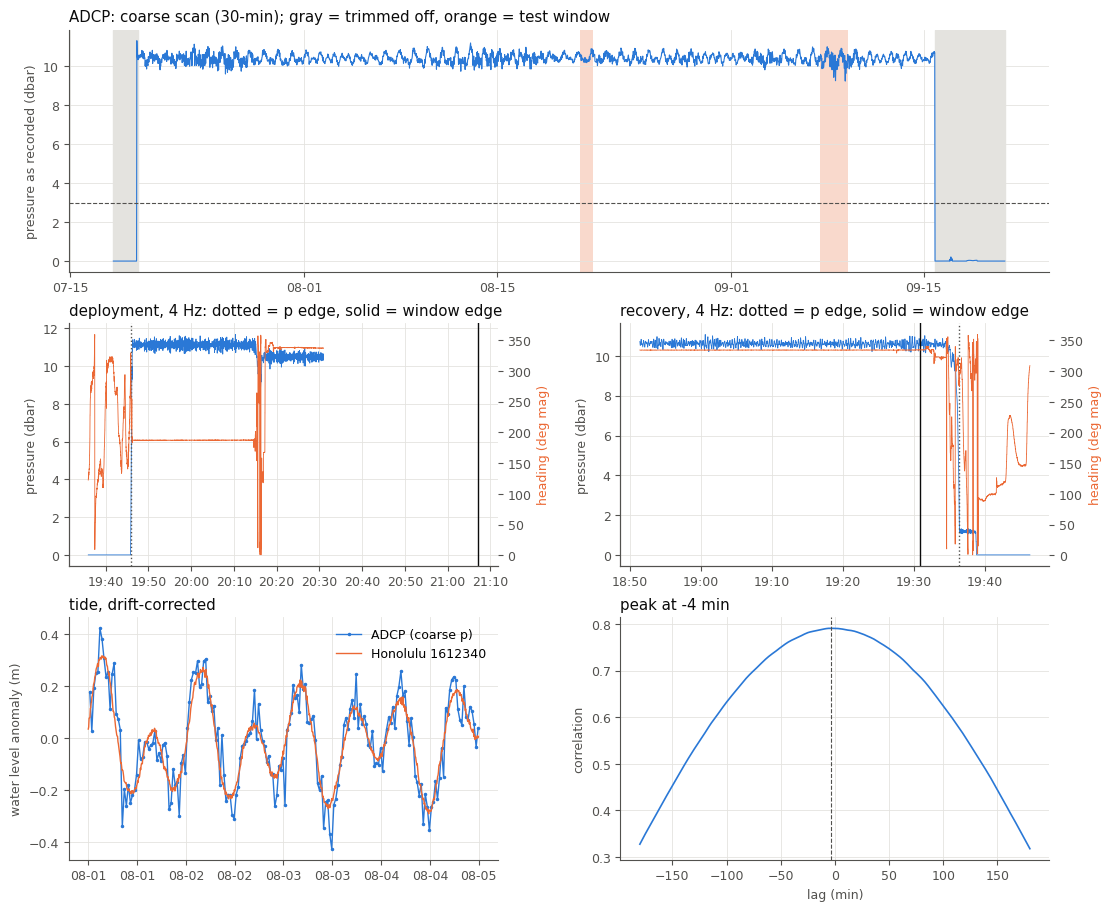

In [9]:
##-----tide-gauge check (coarse scan, whole deployment)-----##
wl_csv = root / "data" / "metadata" / "noaa_1612340_water_level.csv"
wl = pd.read_csv(wl_csv, skipinitialspace=True, parse_dates=["Date Time"]).dropna(subset=["Water Level"])
gauge = wl.set_index("Date Time")["Water Level"]

scw = sc[(sc.index >= t_in) & (sc.index <= t_out)]
eta_c = pd.Series((scw.pressure.values + POFF - patm_at(scw.index.values)) * 1e4 / (RHO * GRAV), index=scw.index)
eta_a = eta_c - eta_c.mean()
gi = lambda L: np.interp((scw.index - pd.Timedelta(minutes=int(L))).values.astype("int64"),
                         gauge.index.values.astype("int64"), gauge.values)
lags = np.arange(-180, 181)
r = np.array([np.corrcoef(eta_a.values, gi(L))[0, 1] for L in lags])
best = int(lags[np.argmax(r)])
g0 = gi(0) - gi(0).mean()
print(f"tide lag {sensor_id} vs Honolulu: {best:+d} min (r = {r.max():.4f}); tidal amplitude ratio "
      f"sensor/gauge {eta_a.std() / g0.std():.3f}  ({len(scw)} coarse samples)")
tide_lag_min = best

fig = plt.figure(figsize=(11, 9), constrained_layout=True)
gs = fig.add_gridspec(3, 2)
ax = fig.add_subplot(gs[0, :])
ax.plot(sc.index, sc.pressure, color=SERIES, lw=0.8)
ax.axvspan(sc.index[0], t_in, color=GRID, zorder=0)
ax.axvspan(t_out, sc.index[-1], color=GRID, zorder=0)
for a, b in TEST_WINDOWS:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="#eb6834", alpha=0.25, lw=0)
ax.axhline(P_WET, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("pressure as recorded (dbar)")
ax.set_title(f"{sensor_id}: coarse scan ({COARSE_STEP_MIN}-min); gray = trimmed off, orange = test window",
             loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
for j, (d_, tp, te_, lab) in enumerate([(edge_in, t_p_in, t_in, "deployment"), (edge_out, t_p_out, t_out, "recovery")]):
    ax = fig.add_subplot(gs[1, j])
    tt = pd.DatetimeIndex(d_.time.values)
    w = (tt > tp - pd.Timedelta(minutes=10)) & (tt < tp + pd.Timedelta(minutes=45)) if j == 0 else \
        (tt > tp - pd.Timedelta(minutes=45)) & (tt < tp + pd.Timedelta(minutes=10))
    ax.plot(tt[w], d_.pressure.values[w], color=SERIES, lw=0.6)
    ax2 = ax.twinx()
    ax2.plot(tt[w], d_.heading.values[w] % 360, color="#eb6834", lw=0.6)
    ax2.set_ylabel("heading (deg mag)", color="#eb6834")
    ax2.grid(False)
    ax.axvline(tp, color=INK2, ls=":", lw=1)
    ax.axvline(te_, color=INK, lw=1)
    ax.set_ylabel("pressure (dbar)")
    ax.set_title(f"{lab}, 4 Hz: dotted = p edge, solid = window edge", loc="left", color=INK)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax = fig.add_subplot(gs[2, 0])
w = slice("2026-08-01", "2026-08-04")
ax.plot(eta_a[w].index, eta_a[w].values, ".-", color=SERIES, lw=1, ms=3, label=f"{sensor_id} (coarse p)")
gw = gauge[w] - gauge.mean()
ax.plot(gw.index, gw.values - (gw.mean() - eta_a[w].mean()), color="#eb6834", lw=1, label="Honolulu 1612340")
ax.set_ylabel("water level anomaly (m)")
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_title("tide, drift-corrected", loc="left", color=INK)
ax = fig.add_subplot(gs[2, 1])
ax.plot(lags, r, color=SERIES, lw=1.2)
ax.axvline(best, color=INK2, ls="--", lw=0.8)
ax.set_xlabel("lag (min)")
ax.set_ylabel("correlation")
ax.set_title(f"peak at {best:+d} min", loc="left", color=INK)
fig.savefig(fig_dir / f"{sensor_id}_trim.png", dpi=150)
plt.show()

### 3. Beam Quality masks
Correlation and SNR thresholds as `adv_QC` (Elgar, Raubenheimer & Guza 2001, 2005), plus the Signature's surface side-lobe cutoff.
#### 3a. Correlation gate, surface side lobes, SNR flag
1. **Range offset.** dolfyn `set_range_offset(H_DEPLOY)`: `range` becomes height above the bed.
2. **Surface.** dolfyn `find_surface_from_P` gives the depth from `p`, T and S. `depth_ast = H_DEPLOY + ast_dist`
   is the AST (acoustic surface tracking) distance along the vertical beam, measured every ping.
   `SURFACE_SOURCE` picks the depth used. **Side lobes** (dolfyn `nan_beyond_surface`): cells above
   `(depth − h) cos 25° − cell size + h` see the surface echo through the side lobes and are masked (NaN, never
   replaced). dolfyn applies the same cos 25° to the vertical beam, which is conservative.
3. **Correlation** (Elgar et al. 2001, 2005): a sample is bad where `corr < CORR_MIN`, with
   `CORR_MIN = 100·(0.3 + 0.4·√(fs/25))` = 46.0 % at 4 Hz. Each beam and cell is judged on its own. Bad samples are
   kept as recorded here and replaced in section 4 (Elgar's method). Caveat: the √fs scaling assumes more pings
   averaged per sample at lower rates (true for the Vector); it is not established for the Signature's 4 Hz burst.
4. **SNR** (flag only, as the Vectors): `SNR = amp − noise floor` (dB), with the noise floor per beam taken as the
   median in-air amplitude before deployment. Samples below `SNR_MIN` (8 dB) set a bit; Elgar's hourly run rule
   (≤ 0.81 % low SNR) is stored as `seg_snr_ok` in the hourly file. It is not a gate.
5. Flags go into `qc` (beam 1–4 slant, 5 vertical) as bits: 1 = low correlation, 2 = above the side-lobe limit,
   4 = 1-s running mean (run > 1 s), 8 = linearly interpolated (run ≤ 1 s), 16 = low SNR.


In [10]:
##-----beam quality: surface + correlation (dolfyn), amplitude diagnostic-----##
QC_CORR, QC_SURF, QC_RUNMEAN, QC_INTERP, QC_SNR = 1, 2, 4, 8, 16
# Elgar et al. (2001, 2005): 0.3 + 0.4 sqrt(fs/25), i.e. SonTek's 0.7 at 25 Hz relaxed as sqrt(fs)
CORR_MIN = 100 * (CORR_A + CORR_B * np.sqrt(fs / CORR_REF_FS))

# noise floor: in-air amplitude before deployment (the edge window from section 2), per beam, over all cells
air = pd.DatetimeIndex(edge_in.time.values) < t_p_in - pd.Timedelta(minutes=5)
noise = np.median(edge_in["amp"].values[:, :, air], axis=(1, 2))
noise_b5 = float(np.median(edge_in["amp_b5"].values[:, air]))

def step_beam(d):
    """Adds depth/depth_p/depth_ast and the qc bit array; NaNs vel and vel_b5 where corr or surface fail."""
    aclean.set_range_offset(d, H_DEPLOY)                       # range -> height above the bed
    aclean.find_surface_from_P(d, salinity=S_TRUE)             # adds water_density and depth (bed -> surface)
    d["depth_p"] = d["depth"].copy()
    ast_ok = (d.ast_dist > AST_RANGE[0]) & (d.ast_dist < AST_RANGE[1])
    d["depth_ast"] = (H_DEPLOY + d.ast_dist).where(ast_ok).astype("float32")
    d["depth_ast"].attrs.update(units="m", long_name="bed to surface from the AST distance (vertical beam)")
    if SURFACE_SOURCE == "ast":
        d["depth"] = d.depth_ast.fillna(d.depth_p)
    elif SURFACE_SOURCE == "min":
        d["depth"] = np.fmin(d.depth_p, d.depth_ast)             # fmin ignores a missing AST
    d["depth"].attrs.update(units="m", long_name=f"bed to surface used for the side-lobe mask ({SURFACE_SOURCE})")

    # side lobes: dolfyn nan_beyond_surface on a velocity-only copy; the NaNs it adds are the mask
    sub = aclean.nan_beyond_surface(d[["vel", "vel_b5", "depth"]])
    surf = np.isnan(sub.vel.values[0]) & np.isfinite(d.vel.values[0])          # (range, time), same for all beams
    surf_b5 = np.isnan(sub.vel_b5.values) & np.isfinite(d.vel_b5.values)
    del sub

    # correlation (Elgar et al. 2001, 2005): bad where corr < CORR_MIN, per beam and cell (as adv_QC)
    lowc = (d["corr"].values < CORR_MIN) & np.isfinite(d.vel.values)            # (beam, range, time)
    lowc_b5 = (d["corr_b5"].values < CORR_MIN) & np.isfinite(d.vel_b5.values)

    snr = d["amp"].values - noise[:, None, None]
    snr_b5 = d["amp_b5"].values - noise_b5
    qc = np.zeros((5,) + surf.shape, np.uint8)
    qc[:4] |= np.where(lowc, QC_CORR, 0).astype(np.uint8)
    qc[4]  |= np.where(lowc_b5, QC_CORR, 0).astype(np.uint8)
    qc[:4] |= np.where(surf[None], QC_SURF, 0).astype(np.uint8)
    qc[4]  |= np.where(surf_b5, QC_SURF, 0).astype(np.uint8)
    qc[:4] |= np.where(snr < SNR_MIN, QC_SNR, 0).astype(np.uint8)
    qc[4]  |= np.where(snr_b5 < SNR_MIN, QC_SNR, 0).astype(np.uint8)

    # only the side-lobe samples are removed here; low-correlation (and low-SNR if APPLY_SNR) samples keep their
    # recorded values, which section 4 needs for Elgar's running mean
    d["vel"] = d["vel"].where(xr.DataArray((qc[:4] & QC_SURF) == 0, dims=d["vel"].dims))
    d["vel_b5"] = d["vel_b5"].where(xr.DataArray((qc[4] & QC_SURF) == 0, dims=d["vel_b5"].dims))
    d["qc"] = xr.DataArray(qc, dims=("beam5", "range", "time"),
                           attrs={"long_name": "QC flag bits per beam (1-4 slant, 5 vertical) and cell",
                                  "flag_masks": [QC_CORR, QC_SURF, QC_RUNMEAN, QC_INTERP, QC_SNR],
                                  "flag_meanings": (f"corr_lt_{CORR_MIN:.1f} above_sidelobe_limit running_mean_1s_run_gt_1s "
                                                    f"linear_interp_run_le_1s snr_lt_{SNR_MIN:g}dB"),
                                  "applied": ("above_sidelobe_limit -> NaN; corr" + (", snr" if APPLY_SNR else "")
                                              + " -> replaced (Elgar et al. 2005)")})
    d = d.assign_coords(beam5=np.arange(1, 6))
    d.attrs.update({"qc_corr_min_pct": float(CORR_MIN),
                    "qc_corr_rule": f"Elgar et al. 2001/2005: {CORR_A} + {CORR_B} sqrt(fs/{CORR_REF_FS:g})", "qc_surface_source": SURFACE_SOURCE, "h_deploy_note":
                    "transducer height above bed, estimate (~0.5 m)", "qc_snr_min_db": SNR_MIN,
                    "qc_snr_applied": str(APPLY_SNR),
                    "qc_amp_noise_floor_db": ", ".join(f"{x:.1f}" for x in list(noise) + [noise_b5])})
    return d

ds = step_beam(ds)
qc = ds["qc"].values
surf = (qc[0] & QC_SURF) > 0
below = ~surf
lowc = (qc[:4] & QC_CORR) > 0
cell_ok = ~((qc[:4] & (QC_CORR | QC_SURF)) > 0).any(axis=0)       # all 4 slant beams pass (no replacement needed)
z = ds.range.values

print(f"{sensor_id}: CORR_MIN = 0.3 + 0.4 sqrt({fs:g}/25) = {CORR_MIN:.1f} %")
print(f"{sensor_id}: {ds.sizes['time']:,} pings x {z.size} cells ({z[0]:.2f} - {z[-1]:.2f} m above the bed)")
print(f"  surface ({SURFACE_SOURCE}): depth median {float(ds.depth.median()):.2f} m, "
      f"min {float(ds.depth.min()):.2f}, max {float(ds.depth.max()):.2f}")
dd = (ds.depth_p - ds.depth_ast).values
print(f"  depth_p - depth_ast: median {np.nanmedian(dd):+.3f} m, 1-99 % {np.nanpercentile(dd, 1):+.2f} to "
      f"{np.nanpercentile(dd, 99):+.2f} m; AST missing {100 * np.isnan(ds.depth_ast.values).mean():.2f} %; "
      f"the AST surface is the lower one in {100 * np.nanmean(dd > 0):.0f} % of pings")
print(f"  top kept cell ({z[-1]:.2f} m) above the side-lobe limit {100 * surf[-1].mean():.1f} % of the time; "
      f"cells always above: {int((surf.mean(1) == 1).sum())}")
for b in range(4):
    print(f"  beam {b + 1}: corr < {CORR_MIN:.1f} % in {100 * lowc[b][below].mean():.2f} % of below-surface samples, "
          f"median corr {np.median(ds['corr'].values[b][below]):.0f} %, noise floor {noise[b]:.1f} dB")
lowc5 = ((qc[4] & QC_CORR) > 0)
print(f"  beam 5 (vertical): corr < {CORR_MIN:.1f} % in {100 * lowc5[~((qc[4] & QC_SURF) > 0)].mean():.2f} %, "
      f"noise floor {noise_b5:.1f} dB")
print(f"  all 4 slant beams pass (no replacement needed), below surface: {100 * cell_ok[below].mean():.2f} % of below-surface samples")
lsnr = ((qc[:4] & QC_SNR) > 0).any(0)
print(f"  low SNR (< {SNR_MIN:g} dB, any beam), below surface: {100 * lsnr[below].mean():.2f} % "
      f"({100 * (lsnr & cell_ok)[below].mean():.2f} % NOT already caught) -> {'replaced' if APPLY_SNR else 'hourly flag only'}")

ADCP: 1,036,765 pings x 19 cells (1.10 - 10.10 m above the bed)
  surface (min): depth median 10.85 m, min 6.47, max 13.37
  depth_p - depth_ast: median -0.063 m, 1-99 % -0.82 to +2.02 m; AST missing 0.00 %; the AST surface is the lower one in 32 % of pings
  top kept cell (10.10 m) above the side-lobe limit 95.3 % of the time; cells always above: 0
  beam 1: corr <= 50 % in 0.36 % of below-surface samples, median corr 98 %, noise floor 30.5 dB


  beam 2: corr <= 50 % in 0.30 % of below-surface samples, median corr 98 %, noise floor 31.0 dB
  beam 3: corr <= 50 % in 0.36 % of below-surface samples, median corr 98 %, noise floor 31.0 dB


  beam 4: corr <= 50 % in 0.39 % of below-surface samples, median corr 98 %, noise floor 31.0 dB
  beam 5 (vertical): corr <= 50 % in 0.17 %, noise floor 31.0 dB
  earth velocity usable (all 4 beams pass, below surface): 99.01 % of below-surface samples
  low SNR (< 5 dB, any beam), below surface: 0.00 % (0.00 % NOT already caught) -> diagnostic only


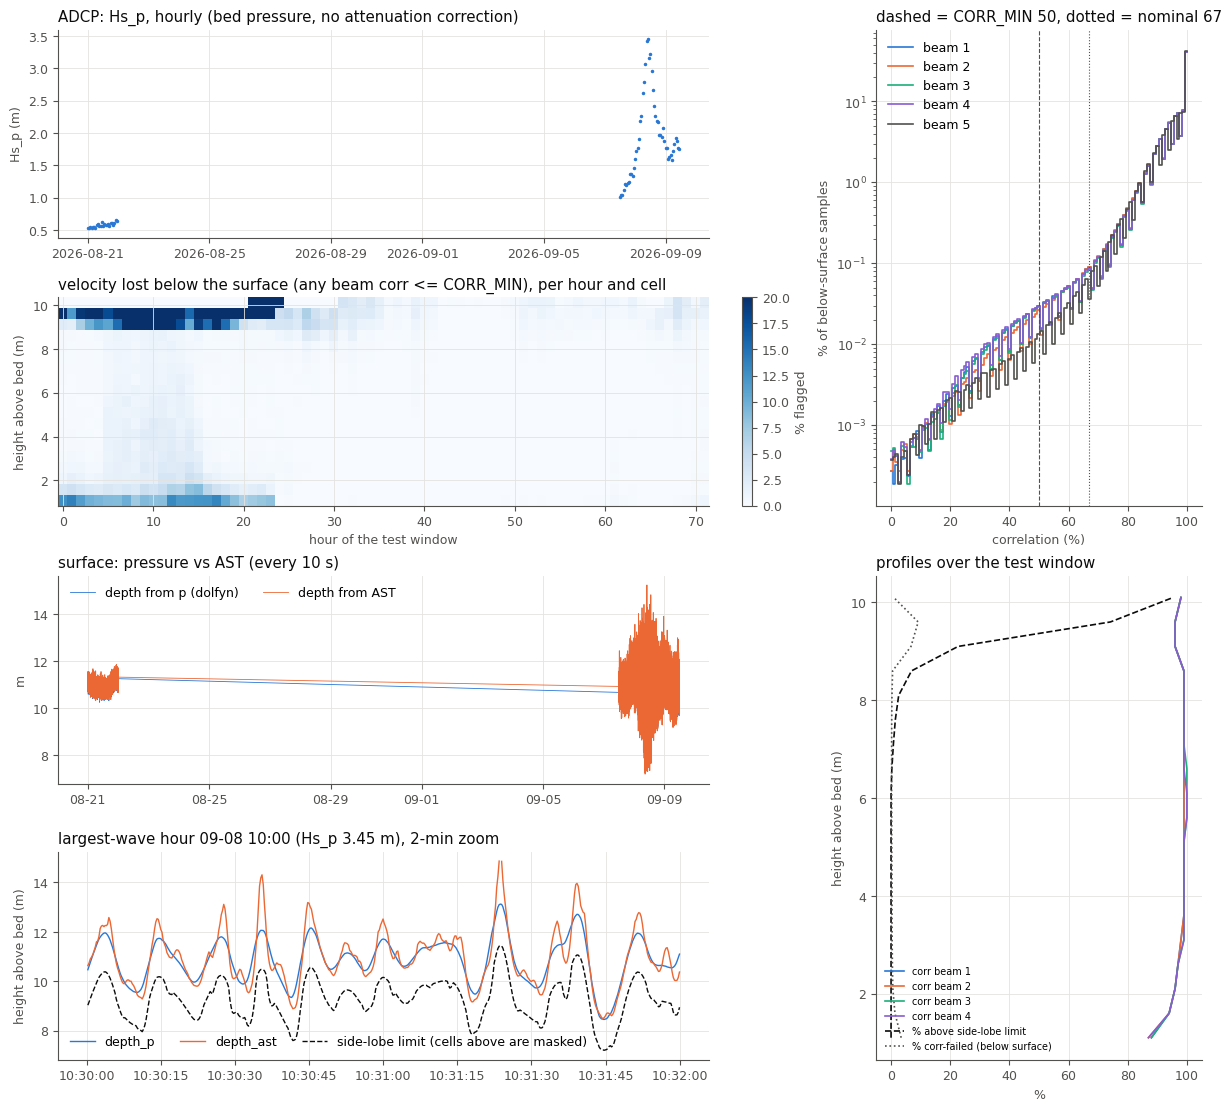

In [11]:
##-----figure: beam quality-----##
# Hs_p: 4 * std of p after a 5-min high-pass, hourly, m of water (no depth-attenuation correction)
p_s = pd.Series(ds.pressure.values.astype(float), index=tq)
p_hp = p_s - p_s.rolling(int(300 * fs), center=True, min_periods=int(60 * fs)).mean()
hs_p = (4 * p_hp.resample("1h").std() * 1e4 / (RHO * GRAV)).dropna()

hour = tq.floor("1h")
fail_h = 100 * pd.DataFrame((~cell_ok & below).T, index=tq).groupby(hour).sum() / \
         pd.DataFrame(below.T, index=tq).groupby(hour).sum().clip(lower=1)   # % of below-surface samples, per cell
fig = plt.figure(figsize=(12, 11), constrained_layout=True)
gs = fig.add_gridspec(4, 3)
ax0 = fig.add_subplot(gs[0, :2])
ax0.plot(hs_p.index, hs_p.values, ".", ms=3, color=SERIES)
ax0.set_ylabel("Hs_p (m)")
ax0.set_title(f"{sensor_id}: Hs_p, hourly (bed pressure, no attenuation correction)", loc="left", color=INK)
ax1 = fig.add_subplot(gs[1, :2])
hh = np.arange(len(fail_h))
im = ax1.pcolormesh(hh, z, fail_h.values.T, shading="nearest", cmap="Blues", vmin=0, vmax=20)
plt.colorbar(im, ax=ax1, label="% flagged")
ax1.set_ylabel("height above bed (m)")
ax1.set_xlabel("hour of the test window")
ax1.set_title(f"velocity flagged below the surface (any beam corr < {CORR_MIN:.1f} %, replaced in section 4), per hour and cell", loc="left", color=INK)
ax2 = fig.add_subplot(gs[2, :2])
ax2.plot(tq[::40], ds.depth_p.values[::40], color=SERIES, lw=0.6, label="depth from p (dolfyn)")
ax2.plot(tq[::40], ds.depth_ast.values[::40], color="#eb6834", lw=0.6, label="depth from AST")
ax2.set_ylabel("m")
ax2.legend(frameon=False, loc="upper left", ncol=2)
ax2.set_title("surface: pressure vs AST (every 10 s)", loc="left", color=INK)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
# 2-min zoom in the largest-wave hour: surface estimates and the side-lobe limit
h_big = hs_p.idxmax()
zz = (tq >= h_big + pd.Timedelta(minutes=30)) & (tq < h_big + pd.Timedelta(minutes=32))
ax3 = fig.add_subplot(gs[3, :2])
ax3.plot(tq[zz], ds.depth_p.values[zz], color=SERIES, lw=1, label="depth_p")
ax3.plot(tq[zz], ds.depth_ast.values[zz], color="#eb6834", lw=1, label="depth_ast")
lim = (ds.depth.values[zz] - H_DEPLOY) * np.cos(np.radians(ds.beam_angle)) - ds.cell_size + H_DEPLOY
ax3.plot(tq[zz], lim, color=INK, lw=1, ls="--", label="side-lobe limit (cells above are masked)")
ax3.set_ylabel("height above bed (m)")
ax3.legend(frameon=False, loc="lower left", ncol=3)
ax3.set_title(f"largest-wave hour {h_big:%m-%d %H}:00 (Hs_p {hs_p[h_big]:.2f} m), 2-min zoom", loc="left", color=INK)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
# right: correlation histograms, correlation and flag profiles
ax4 = fig.add_subplot(gs[:2, 2])
for b in range(4):
    h = np.bincount(ds["corr"].values[b][below].astype(int), minlength=101)[:101]
    ax4.step(np.arange(101), 100 * h / h.sum(), where="mid", color=BEAM_COLORS[b], lw=1.2, label=f"beam {b + 1}")
h = np.bincount(ds["corr_b5"].values[~((qc[4] & QC_SURF) > 0)].astype(int), minlength=101)[:101]
ax4.step(np.arange(101), 100 * h / h.sum(), where="mid", color=BEAM_COLORS[4], lw=1.2, label="beam 5")
ax4.axvline(CORR_MIN, color=INK2, ls="--", lw=0.8)
ax4.axvline(ds.nominal_corr, color=INK2, ls=":", lw=0.8)
ax4.set_yscale("log")
ax4.set_xlabel("correlation (%)")
ax4.set_ylabel("% of below-surface samples")
ax4.set_title(f"dashed = CORR_MIN {CORR_MIN:.1f} (Elgar), dotted = nominal {ds.nominal_corr}", loc="left", color=INK)
ax4.legend(frameon=False, loc="upper left")
ax5 = fig.add_subplot(gs[2:, 2])
cm = np.array([[np.median(ds["corr"].values[b, i][below[i]]) if below[i].any() else np.nan
                for i in range(z.size)] for b in range(4)])
for b in range(4):
    ax5.plot(cm[b], z, color=BEAM_COLORS[b], lw=1.2, label=f"corr beam {b + 1}")
ax5.plot(100 * surf.mean(1), z, color=INK, lw=1.2, ls="--", label="% above side-lobe limit")
ax5.plot(100 * (~cell_ok & below).sum(1) / below.sum(1).clip(1), z, color=INK2, lw=1.2, ls=":", label="% corr-failed (below surface)")
ax5.set_xlabel("%")
ax5.set_ylabel("height above bed (m)")
ax5.set_title("profiles over the test window", loc="left", color=INK)
ax5.legend(frameon=False, loc="lower left", fontsize=7)
fig.savefig(fig_dir / f"{sensor_id}_beam.png", dpi=150)
plt.show()

### 4. Elgar replacement of low-correlation samples (no despiking)
As `adv_QC` (Elgar, Raubenheimer & Guza 2001, 2005). Despiking was removed on 2026-10-03 to match the Vectors.
Applied **per beam and cell** in beam coordinates, before rotation, to samples flagged in section 3:
1. **Runs ≤ `ELGAR_INTERP_MAX_S` (1 s)** of low-correlation samples (1–4 samples at 4 Hz) are **linearly
   interpolated** between the good samples before and after.
2. **Longer runs** get a **1-s running mean of the recorded values themselves**: a centred 1-s window, 5 taps,
   weights [⅛, ¼, ¼, ¼, ⅛], renormalized at block ends and over surface-masked samples.
3. A short run with no good neighbour (at a block end, or next to a surface-masked sample) gets the running mean.
   Nothing is interpolated or averaged across a time break (window boundary, corrupt stretch, burst gap).
4. **Surface-masked samples are never replaced**: there is no water there to measure. They stay NaN.
5. **Where the replaced values are:** `qc` bit 8 = linearly interpolated, bit 4 = 1-s running mean (per beam and
   cell). After this step every below-surface sample has a velocity, so u, v, w are NaN only above the side-lobe limit.

Checks below: % replaced per beam and height, hourly table at the lowest cell, and a zoom of the lowest cell
around a long low-correlation run.


In [12]:
##-----Elgar replacement of low-correlation samples, per beam and cell-----##
seg_n = int(3600 * fs)                                   # samples per 1-h segment
n_use = seg_n - 8                                        # samples per hour used by the section 5 checks
n_lin = int(round(ELGAR_INTERP_MAX_S * fs))              # longest run (samples) that is interpolated: 4 at 4 Hz
n_w = int(round(ELGAR_RUNMEAN_S * fs))
w_rm = np.ones(n_w + 1); w_rm[[0, -1]] = 0.5; w_rm /= w_rm.sum()   # 1-s centred window, [1/8, 1/4, 1/4, 1/4, 1/8]

def expand(starts, lengths):
    """indices covered by runs (start, length)"""
    return np.repeat(starts, lengths) + (np.arange(lengths.sum()) - np.repeat(np.cumsum(lengths) - lengths, lengths))

def elgar_row(x, bad, never, blocks):
    """One beam/cell series (Elgar et al. 2001, 2005). x = recorded velocity, bad = low correlation,
    never = above the side-lobe limit (stays NaN). blocks = (start, stop) stretches with no time break.
    Returns the replaced series and the class per sample: 0 kept, 1 linear interp, 2 1-s running mean."""
    y = x.astype(float).copy()
    cls = np.zeros(x.size, np.int8)
    bad = bad & ~never
    valid = ~never & np.isfinite(x)
    for a, b in blocks:
        bb = bad[a:b]
        if not bb.any():
            continue
        xs, vs = x[a:b].astype(float), valid[a:b]
        good = vs & ~bb
        g0, g1 = runs(bb)
        L = g1 - g0 + 1
        nb_ok = (g0 > 0) & (g1 < bb.size - 1)
        nb_ok[nb_ok] &= good[g0[nb_ok] - 1] & good[g1[nb_ok] + 1]   # a good sample on both sides
        short = (L <= n_lin) & nb_ok
        i_lin, i_rm = expand(g0[short], L[short]), expand(g0[~short], L[~short])
        if i_lin.size:
            ig = np.flatnonzero(good)
            y[a + i_lin] = np.interp(i_lin, ig, xs[ig])
        if i_rm.size:
            num = np.convolve(np.where(vs, xs, 0.0), w_rm, "same")
            den = np.convolve(vs.astype(float), w_rm, "same")
            with np.errstate(invalid="ignore", divide="ignore"):
                y[a + i_rm] = (num / den)[i_rm]
        cls[a + i_lin] = 1
        cls[a + i_rm] = 2
    y[never] = np.nan
    return y, cls

def step_replace(d, brk):
    """Elgar replacement of vel (4 beams) and vel_b5 per cell; sets the QC_INTERP / QC_RUNMEAN bits."""
    qc = d["qc"].values
    gate = QC_CORR | (QC_SNR if APPLY_SNR else 0)
    cut = np.flatnonzero(brk)
    blocks = list(zip(np.r_[0, cut], np.r_[cut, brk.size]))
    vel = d["vel"].values.copy()
    vb5 = d["vel_b5"].values.copy()
    for b in range(5):
        X = vb5 if b == 4 else vel[b]                    # (range, time), a view
        for r in range(X.shape[0]):
            X[r], cls = elgar_row(X[r], (qc[b, r] & gate) > 0, (qc[b, r] & QC_SURF) > 0, blocks)
            qc[b, r] |= np.where(cls == 1, QC_INTERP, np.where(cls == 2, QC_RUNMEAN, 0)).astype(np.uint8)
    d["vel"] = xr.DataArray(vel.astype("float32"), dims=d["vel"].dims, coords=d["vel"].coords, attrs=d["vel"].attrs)
    d["vel_b5"] = xr.DataArray(vb5.astype("float32"), dims=d["vel_b5"].dims, coords=d["vel_b5"].coords,
                               attrs=d["vel_b5"].attrs)
    d["qc"].values = qc
    d.attrs.update({"qc_despike": "none (removed 2026-10-03 to match adv_QC)",
                    "qc_replace_rule": (f"Elgar et al. 2001/2005, per beam and cell: low-corr runs <= {ELGAR_INTERP_MAX_S:g} s "
                                        f"linear interpolation; longer runs {ELGAR_RUNMEAN_S:g}-s running mean (weights "
                                        f"{np.round(w_rm, 3).tolist()}) of the recorded values; surface-masked samples stay NaN")})
    return d

# recorded values of the lowest cell, kept for the figure below
rec_ref = np.concatenate([ds.vel.values[:, REF_CELL], ds.vel_b5.values[REF_CELL][None]])
t0_ = time.time()
ds = step_replace(ds, brk)
qc = ds["qc"].values
itp = (qc & QC_INTERP) > 0
rmn = (qc & QC_RUNMEAN) > 0
sub_ok = ~((qc & QC_SURF) > 0)
print(f"{sensor_id}: Elgar replacement in {time.time() - t0_:.0f} s (runs <= {ELGAR_INTERP_MAX_S:g} s linear, "
      f"longer {ELGAR_RUNMEAN_S:g}-s running mean)")
for b in range(5):
    m = sub_ok[b]
    print(f"  beam {b + 1}: linear interp {100 * itp[b][m].mean():.3f} % | running mean {100 * rmn[b][m].mean():.3f} % "
          f"| NaN left {100 * np.isnan((ds.vel_b5.values if b == 4 else ds.vel.values[b])[m]).mean():.3f} % "
          "(below-surface samples)")
cell_ok2 = np.isfinite(ds.vel.values).all(0)
rm_any = rmn[:4].any(0)
rm_seg = (pd.DataFrame((rm_any & below).T, index=tq).groupby(hour).sum() /
          pd.DataFrame(below.T, index=tq).groupby(hour).sum().clip(lower=1))
print(f"  earth velocity defined after replacement: {100 * cell_ok2[below].mean():.2f} % of below-surface samples; "
      f"1-h segments with <= {100 * RUNMEAN_MAX_FRAC:g} % running mean at the lowest cell: "
      f"{int((rm_seg[REF_CELL] <= RUNMEAN_MAX_FRAC).sum())} of {len(rm_seg)}")


ADCP: despiked in 28 s; threshold 6.56 sigma (universal)
  beam 1: spikes 0.000 % | filled 0.340 % | NaN left 0.02 % (below-surface samples)
  beam 2: spikes 0.000 % | filled 0.287 % | NaN left 0.01 % (below-surface samples)


  beam 3: spikes 0.000 % | filled 0.334 % | NaN left 0.02 % (below-surface samples)
  beam 4: spikes 0.000 % | filled 0.360 % | NaN left 0.03 % (below-surface samples)
  beam 5: spikes 0.000 % | filled 0.166 % | NaN left 0.01 % (below-surface samples)


  earth velocity usable after despike+fill: 99.93 % of below-surface samples; 1-h segments with <= 10 % NaN at the lowest cell: 72 of 72


correlation dip (< 80 %) at spikes vs all tested samples:


  beam 1:  60.0 % vs  2.9 % -> x20.8
  beam 2:  50.8 % vs  2.9 % -> x17.5
  beam 3:  70.1 % vs  2.7 % -> x25.5


  beam 4:  63.4 % vs  2.8 % -> x22.3
spike rate by height (%, slant beams / vertical):
   1.1 m: 0.001 / 0.002
   2.6 m: 0.000 / 0.000
   4.1 m: 0.000 / 0.000
   5.6 m: 0.000 / 0.000
   7.1 m: 0.000 / 0.000
   8.6 m: 0.000 / 0.000
  10.1 m: 0.000 / 0.000


lowest cell (1.10 m), after/before over gap-free hours:
  beam 1: 71 h | wave band median 1.0000 (min 0.9971) | 0.5-2 Hz median 1.000 | skewness change median +0.0000, worst 0.1105
  beam 2: 69 h | wave band median 1.0000 (min 0.9884) | 0.5-2 Hz median 1.000 | skewness change median +0.0000, worst 0.1652
  beam 3: 69 h | wave band median 1.0000 (min 0.9967) | 0.5-2 Hz median 1.000 | skewness change median +0.0000, worst 0.0260
  beam 4: 69 h | wave band median 1.0000 (min 0.9897) | 0.5-2 Hz median 1.000 | skewness change median +0.0000, worst 0.2599
  beam 5: 68 h | wave band median 1.0000 (min 0.9852) | 0.5-2 Hz median 1.000 | skewness change median +0.0000, worst 0.2441


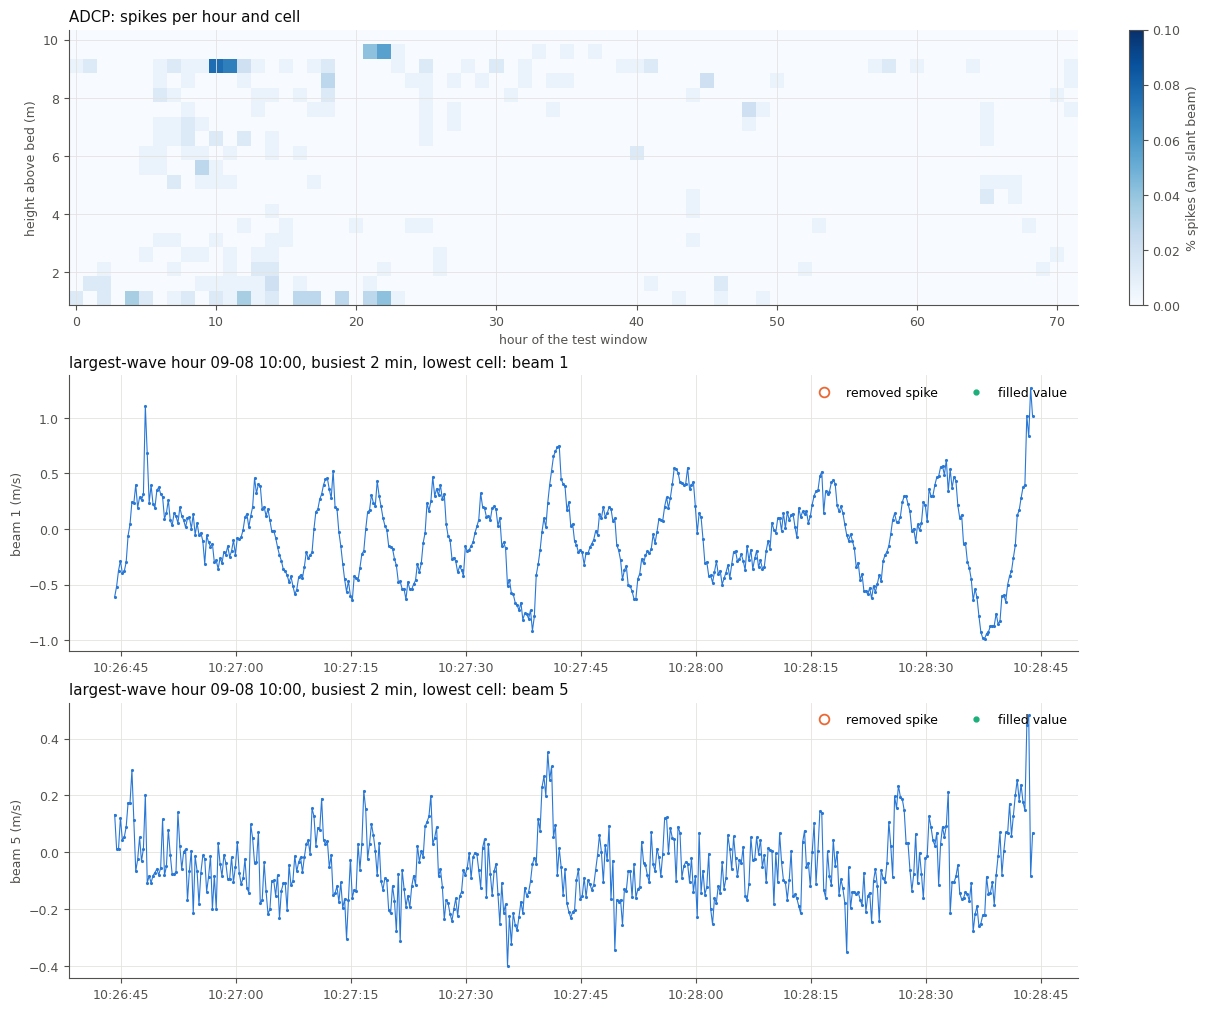

In [13]:
##-----replacement checks + figure-----##
print("replaced (%, any slant beam, below-surface samples) by height: linear interp / running mean")
for i in range(0, z.size, 3):
    m = sub_ok[0, i]
    print(f"  {z[i]:4.1f} m: {100 * itp[:4, i].any(0)[m].mean():.3f} / {100 * rmn[:4, i].any(0)[m].mean():.3f}")

fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 1)
ax = fig.add_subplot(gs[0])
rp_h = 100 * pd.DataFrame(((itp[:4] | rmn[:4]).any(0) & below).T, index=tq).groupby(hour).mean()
im = ax.pcolormesh(np.arange(len(rp_h)), z, rp_h.values.T, shading="nearest", cmap="Blues", vmin=0,
                   vmax=max(np.nanpercentile(rp_h.values, 99), 0.1))
plt.colorbar(im, ax=ax, label="% replaced (any slant beam)")
ax.set_xlabel("hour of the test window")
ax.set_ylabel("height above bed (m)")
ax.set_title(f"{sensor_id}: low-correlation samples replaced (Elgar), per hour and cell", loc="left", color=INK)
# zoom: 2 min around the longest running-mean run (<= 200 samples) at the lowest cell, beam 1 and beam 5
for j, b in enumerate([0, 4]):
    ax = fig.add_subplot(gs[j + 1])
    g0, g1 = runs(rmn[b, REF_CELL])
    L = g1 - g0 + 1
    cand = np.flatnonzero(L <= 200)
    if not cand.size:
        g0, g1 = runs(itp[b, REF_CELL]); L = g1 - g0 + 1; cand = np.arange(L.size)
    if not cand.size:
        ax.set_title(f"beam {b + 1}: nothing replaced at the lowest cell", loc="left", color=INK)
        continue
    k = cand[np.argmax(L[cand])]
    mid = (g0[k] + g1[k]) // 2
    zz = np.zeros(tq.size, bool); zz[max(mid - int(60 * fs), 0):mid + int(60 * fs)] = True
    after = ds.vel_b5.values[REF_CELL] if b == 4 else ds.vel.values[b, REF_CELL]
    ax.plot(tq[zz], rec_ref[b][zz], color=GRID, lw=1.2, label="recorded")
    ax.plot(tq[zz], after[zz], color=SERIES, lw=0.9, label="after replacement")
    for m_, col, lab in [(itp[b, REF_CELL], BEAM_COLORS[1], "linear interp"), (rmn[b, REF_CELL], BEAM_COLORS[2], "1-s running mean")]:
        ax.plot(tq[zz & m_], after[zz & m_], "o", ms=3, color=col, label=lab)
    ax.set_ylabel(f"beam {b + 1} (m/s)")
    ax.set_title(f"lowest cell, beam {b + 1}: 2 min around a long low-correlation run", loc="left", color=INK)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M:%S"))
    ax.legend(frameon=False, loc="upper right", ncol=4)
fig.savefig(fig_dir / f"{sensor_id}_replace.png", dpi=150)
plt.show()
del rec_ref
gc.collect();


### 5. Rotation to earth/shore-normal
- The compass and tilt sensor are in the transducer housing, so dolfyn's own chain is used: `set_declination`
  (the instrument ran with `DECL=0.00`, so its heading is magnetic) and then `rotate2(ds, "earth")`,
  beam → inst → earth with the per-ping heading/pitch/roll. The result is E, N and two vertical estimates
  U1, U2, one from each beam pair. `w = (U1 + U2)/2`; `w_err = U1 − U2` is the error velocity.
- Beam 5 points up, so `vel_b5` is already vertical, to within the ~0.5° tilt. It is kept as `w_b5`.
- Shore-normal: the transect C value from `sensor_notes.csv` (350°). +u onshore, +v 90° counter-clockwise
  (alongshore), +w up, as for the Vectors.

**Checks:** internal heading vs KVH; w vs dp/dt coherence (+1 when +z is up); hourly wave direction from the
p–u co-spectrum at the lowest cell, **compared with the co-located VC10**; the mean-current principal axis (dolfyn
`calc_principal_heading`). The heading/pitch/roll record from the coarse scan shows any frame movement.

In [14]:
##-----rotation: beam -> inst -> earth (dolfyn, internal compass) -> shore-normal-----##
from dolfyn.rotate.vector import _euler2orient
kvh_mag = float(row["Magnetic Heading (KVH)"])
SHORE_NORMAL_DEG = (float(row["Shore Normal Onshore (deg true)"]) if SHORE_NORMAL_OVERRIDE is None
                    else float(SHORE_NORMAL_OVERRIDE))
head_int_med = float(np.degrees(np.angle(np.mean(np.exp(1j * np.radians(sc.heading[(sc.index > t_in) & (sc.index < t_out)]))))) % 360)
head_offset = ((kvh_mag - head_int_med + 180) % 360 - 180) if HEADING_SOURCE == "kvh" else 0.0

def step_rotate(d):
    if head_offset:
        d["heading"] = d["heading"] + head_offset
        d["orientmat"] = _euler2orient(d["time"], d["heading"].values, d["pitch"].values, d["roll"].values)
    set_declination(d, DECLINATION_DEG, inplace=True)
    with contextlib.redirect_stdout(io.StringIO()):
        rotate2(d, "earth", inplace=True)
    E, N, U1, U2 = d["vel"].values
    sn = np.radians(SHORE_NORMAL_DEG)
    out = {"u_east": (E, "eastward velocity (true)"), "v_north": (N, "northward velocity (true)"),
           "u": (E * np.sin(sn) + N * np.cos(sn), f"cross-shore velocity, + onshore toward {SHORE_NORMAL_DEG:g} deg true"),
           "v": (-E * np.cos(sn) + N * np.sin(sn), f"alongshore velocity, + toward {(SHORE_NORMAL_DEG - 90) % 360:g} deg true"),
           "w": (0.5 * (U1 + U2), "vertical velocity, + up (mean of the two beam-pair estimates)"),
           "w_err": (U1 - U2, "error velocity: difference of the two beam-pair vertical estimates"),
           "w_b5": (d["vel_b5"].values, "vertical velocity from beam 5, + up")}
    for k, (a, ln) in out.items():
        d[k] = (("range", "time"), a.astype("float32"), {"units": "m s-1", "long_name": ln})
    d.attrs.update({"rot_heading_source": HEADING_SOURCE, "rot_heading_offset_deg": head_offset,
                    "rot_declination_deg": DECLINATION_DEG, "rot_shore_normal_deg": SHORE_NORMAL_DEG,
                    "coord_sys_note": "u, v, w shore-normal; u_east/v_north true ENU; qc/amp/corr per beam"})
    return d

ds = step_rotate(ds)
print(f"{sensor_id}: heading source {HEADING_SOURCE}; internal (magnetic) median {head_int_med:.2f} deg over the "
      f"deployment vs KVH {kvh_mag:.1f} deg: internal - KVH = {(head_int_med - kvh_mag + 180) % 360 - 180:+.2f} deg")
print(f"  true heading used (test window median): {float(np.median(ds.heading.values % 360)):.2f} deg "
      f"(declination {DECLINATION_DEG:+.2f}); shore-normal {SHORE_NORMAL_DEG:g} deg true (transect {row['Transect'].strip()})")
print(f"  coord_sys now {ds.coord_sys}; vel dirs {list(ds.vel.dir.values)}")
# frame movement: largest change of the 6-h median attitude over the deployment
att = sc[(sc.index > t_in) & (sc.index < t_out)][["heading", "pitch", "roll"]].resample("6h").median()
for c in ["heading", "pitch", "roll"]:
    dlt = att[c].diff()
    print(f"  {c}: deployment 1-99 % {np.nanpercentile(att[c], 1):.2f} - {np.nanpercentile(att[c], 99):.2f} deg; "
          f"largest 6-h step {dlt.abs().max():.2f} deg at {dlt.abs().idxmax()}")

ADCP: heading source internal; internal (magnetic) median 334.46 deg over the deployment vs KVH 337.6 deg: internal - KVH = -3.14 deg
  true heading used (test window median): 343.66 deg (declination +9.26); shore-normal 350 deg true (transect C)
  coord_sys now earth; vel dirs ['E', 'N', 'U1', 'U2']
  heading: deployment 1-99 % 334.38 - 334.54 deg; largest 6-h step 0.12 deg at 2026-08-20 18:00:00
  pitch: deployment 1-99 % 0.24 - 0.56 deg; largest 6-h step 0.21 deg at 2026-09-08 06:00:00
  roll: deployment 1-99 % 0.19 - 0.35 deg; largest 6-h step 0.08 deg at 2026-09-08 06:00:00


ADCP: 64 gap-free hours, lowest cell (1.10 m above the bed)
  1. w vs dp/dt coherence: median +0.77 (4-beam), +0.67 (beam 5)  (expect ~ +1 if +z is up)
  2. wave direction of travel: energy-weighted mean 356.6 deg true, hourly 5-95 % 3-355 (shore-normal 350)
     vs VC10 (same hours): ADCP - VC10 median -9.6 deg, IQR -9.8 to -1.1 (59 h)
  3. depth-mean current principal axis (10-min means, 13 cells): 67.2 deg, anisotropy 1.82; onshore normal 337.2 deg true
  mean current (depth mean): E +0.42, N -5.06 cm/s


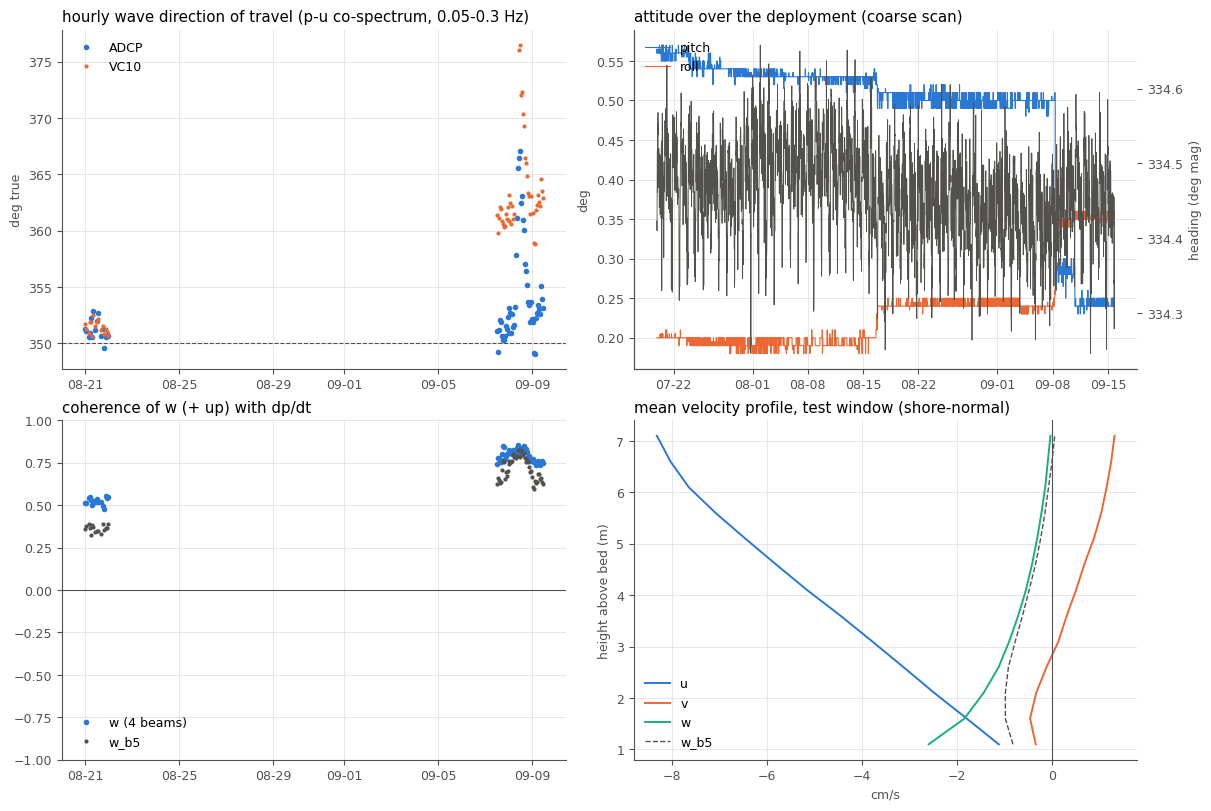

In [15]:
##-----rotation checks: vertical sign, wave direction (vs VC10), current axis-----##
f_c = np.fft.rfftfreq(n_use, 1 / fs)
wb = (f_c >= 0.05) & (f_c <= 0.3)
V = {"E": ds.u_east.values[REF_CELL], "N": ds.v_north.values[REF_CELL], "U": ds.w.values[REF_CELL],
     "U5": ds.w_b5.values[REF_CELL], "p": ds.pressure.values.astype(float)}
rows = []
for h, g in pd.Series(np.arange(tq.size), index=tq).groupby(hour):
    ii = g.values
    if ii.size < n_use or brk[ii[1:n_use]].any():
        continue
    ii = ii[:n_use]
    if any(np.isnan(V[k][ii]).any() for k in V):
        continue
    F = {k: np.fft.rfft(V[k][ii] - V[k][ii].mean())[wb] for k in V}
    co = lambda a, b: np.real(np.sum(F[a] * np.conj(F[b])))
    Pdot = F["p"] * 1j * 2 * np.pi * f_c[wb]
    coh = lambda k: np.real(np.sum(F[k] * np.conj(Pdot))) / np.sqrt(np.sum(abs(F[k]) ** 2) * np.sum(abs(Pdot) ** 2))
    rows.append((h, coh("U"), coh("U5"), np.degrees(np.arctan2(co("E", "p"), co("N", "p"))) % 360, np.sqrt(co("p", "p"))))
wv = pd.DataFrame(rows, columns=["hour", "coh_w", "coh_w5", "wave_dir", "p_amp"]).set_index("hour")

def circ_mean(a, w=None):
    w = np.ones_like(a) if w is None else w
    r = np.radians(a)
    return np.degrees(np.arctan2(np.sum(w * np.sin(r)), np.sum(w * np.cos(r)))) % 360

wave_dir_mean = circ_mean(wv.wave_dir.values, wv.p_amp.values ** 2)
# the co-located Vector (VC10): hourly wave direction from its own section 5
vc = xr.open_dataset(qc_dir / f"{SYNC_SENSOR}_QC.nc")
vc_dir = vc["wave_dir_h"].to_series().reindex(wv.index)
ddir = ((wv.wave_dir - vc_dir + 180) % 360 - 180).dropna()

# mean current: depth mean over cells that stay below the side-lobe limit >= 99 % of the time
deep = surf.mean(1) <= 0.01
m10 = pd.DataFrame({"E": np.nanmean(ds.u_east.values[deep], 0), "N": np.nanmean(ds.v_north.values[deep], 0)},
                   index=tq).resample("10min").mean().dropna()
x_all = np.vstack([m10.E.values, m10.N.values])
e_all = np.linalg.eigvalsh(np.cov(x_all))
cur_axis, cur_aniso = float(calc_principal_heading(x_all, tidal_mode=True)), np.sqrt(e_all[1] / e_all[0])
cur_normal = min([(cur_axis + 90) % 360, (cur_axis - 90) % 360], key=lambda a: abs((a - wave_dir_mean + 180) % 360 - 180))

print(f"{sensor_id}: {len(wv)} gap-free hours, lowest cell ({z[REF_CELL]:.2f} m above the bed)")
print(f"  1. w vs dp/dt coherence: median {wv.coh_w.median():+.2f} (4-beam), {wv.coh_w5.median():+.2f} (beam 5)  "
      "(expect ~ +1 if +z is up)")
print(f"  2. wave direction of travel: energy-weighted mean {wave_dir_mean:.1f} deg true, hourly 5-95 % "
      f"{np.percentile(wv.wave_dir, 5):.0f}-{np.percentile(wv.wave_dir, 95):.0f} (shore-normal {SHORE_NORMAL_DEG:g})")
print(f"     vs {SYNC_SENSOR} (same hours): ADCP - {SYNC_SENSOR} median {ddir.median():+.1f} deg, "
      f"IQR {ddir.quantile(.25):+.1f} to {ddir.quantile(.75):+.1f} ({len(ddir)} h)")
print(f"  3. depth-mean current principal axis (10-min means, {int(deep.sum())} cells): {cur_axis:.1f} deg, anisotropy "
      f"{cur_aniso:.2f}; onshore normal {cur_normal:.1f} deg true")
print(f"  mean current (depth mean): E {100 * m10.E.mean():+.2f}, N {100 * m10.N.mean():+.2f} cm/s")

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax = axs[0, 0]
ax.plot(wv.index, (wv.wave_dir - SHORE_NORMAL_DEG + 180) % 360 - 180 + SHORE_NORMAL_DEG, "o", ms=3, color=SERIES, label=sensor_id)
ax.plot(vc_dir.index, (vc_dir - SHORE_NORMAL_DEG + 180) % 360 - 180 + SHORE_NORMAL_DEG, ".", ms=4, color="#eb6834", label=SYNC_SENSOR)
ax.axhline(SHORE_NORMAL_DEG, color=INK2, ls="--", lw=0.8)
ax.set_ylabel("deg true")
ax.legend(frameon=False)
ax.set_title(f"hourly wave direction of travel (p-u co-spectrum, 0.05-0.3 Hz)", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[1, 0]
ax.plot(wv.index, wv.coh_w, "o", ms=3, color=SERIES, label="w (4 beams)")
ax.plot(wv.index, wv.coh_w5, ".", ms=4, color=BEAM_COLORS[4], label="w_b5")
ax.set_ylim(-1, 1)
ax.axhline(0, color=INK2, lw=0.8)
ax.legend(frameon=False, loc="lower left")
ax.set_title("coherence of w (+ up) with dp/dt", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[0, 1]
att_all = sc[(sc.index > t_in) & (sc.index < t_out)]
ax.plot(att_all.index, att_all.pitch, color=SERIES, lw=0.8, label="pitch")
ax.plot(att_all.index, att_all["roll"], color="#eb6834", lw=0.8, label="roll")
ax.set_ylabel("deg")
ax2 = ax.twinx()
ax2.plot(att_all.index, att_all.heading, color=INK2, lw=0.6)
ax2.set_ylabel("heading (deg mag)", color=INK2)
ax2.grid(False)
ax.legend(frameon=False, loc="upper left")
ax.set_title("attitude over the deployment (coarse scan)", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax = axs[1, 1]
for k, cc in [("u", SERIES), ("v", "#eb6834"), ("w", BEAM_COLORS[2])]:
    ax.plot(100 * np.nanmean(ds[k].values, 1)[deep], z[deep], color=cc, lw=1.4, label=k)
ax.plot(100 * np.nanmean(ds.w_b5.values, 1)[deep], z[deep], color=BEAM_COLORS[4], lw=1, ls="--", label="w_b5")
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel("cm/s")
ax.set_ylabel("height above bed (m)")
ax.legend(frameon=False)
ax.set_title("mean velocity profile, test window (shore-normal)", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_rotate.png", dpi=150)
plt.show()

### 6. z² test, linear wave theory (Elgar, Raubenheimer & Guza 2005, §3.3)
Same formula and code as `adv_QC`. Eq. (1), integrated over the wind-wave band 0.05 < f < 0.20 Hz:
$$z^2 = \frac{\sum S_{pp}}{\sum (S_{uu}+S_{vv})\,(\omega/gk)^2\,\cosh^2(k d_p)/\cosh^2(k d_u)}$$
with $d_p$ = `Z_P_HAB` (pressure sensor) and $d_u$ = each cell's height above the bed ($\exp(k d_p)$ if $d_p < 0$).
Data are rejected unless **0.5 < z² < 2.0**. Per clock hour (in place of Elgar's 3072-s records) and per cell that
stays below the side-lobe limit (≥ 99 % of the time): `seg_ok(hour, cell) = seg_runmean_ok & z2_ok`, stored in
`ADCP_qc_hourly.nc`. Cells that are not tested have no z² and fail `seg_ok`. An hour is used if it has ≥ 99 % of its
samples, no internal gap > 2 s, and ≤ `NAN_MAX_FRAC` NaN. The synthetic-wave closure test runs first.
The figure shows the lowest cell.


In [16]:
##-----z^2 test (Elgar et al. 2005, section 3.3; functions as in adv_QC)-----##
from scipy.signal import welch, detrend

def wavenumber(omega, h, g=GRAV):
    omega = np.asarray(omega, float)
    k = np.maximum(omega ** 2 / g, omega / np.sqrt(g * h))
    for _ in range(40):
        th = np.tanh(k * h)
        k = k - (g * k * th - omega ** 2) / (g * th + g * k * h * (1 - th ** 2))
    return k

def seg_spectra(p_m, u, v):
    kw = dict(fs=fs, window="hann", nperseg=ZT_NFFT, noverlap=int(ZT_NFFT * ZT_OVERLAP), detrend=False)
    f, Spp = welch(detrend(p_m, type="linear"), **kw)
    _, Suu = welch(detrend(u, type="linear"), **kw)
    _, Svv = welch(detrend(v, type="linear"), **kw)
    return f, Spp, Suu + Svv

def z2_from_spectra(f, Spp, Suv, h, z_p, z_u, band):
    """Elgar et al. (2005) Eq. (1), integrated over `band`: z^2 = sum(Spp) / sum(Spp_pred),
    Spp_pred = (Suu + Svv) (omega / g k)^2 Cp^2 / cosh^2(k z_u), Cp = cosh(k z_p) (exp(k z_p) if z_p < 0)."""
    b = (f >= band[0]) & (f <= band[1])
    om = 2 * np.pi * f[b]
    h = np.atleast_1d(h)[:, None]
    k = wavenumber(om[None, :], h)
    Cp = np.exp(k * z_p) if z_p < 0 else np.cosh(k * z_p)
    pred = np.atleast_2d(Suv)[:, b] * (om / (GRAV * k)) ** 2 * (Cp / np.cosh(k * z_u)) ** 2
    Spp_b = np.atleast_2d(Spp)[:, b]
    S_eta = Spp_b * (np.cosh(k * h) / Cp) ** 2
    return np.sum(Spp_b, 1) / np.sum(pred, 1), S_eta, pred

_t = np.arange(int(3600 * fs)) / fs
for _h, _zp, _zu in [(10.0, 0.5, 0.5), (10.0, 0.5, 1.1), (10.0, 0.5, 6.0)]:
    _p = np.zeros_like(_t); _u = np.zeros_like(_t)
    for _f, _a in [(0.07, 0.3), (0.10, 0.5), (0.15, 0.3)]:
        _om = 2 * np.pi * _f; _k = float(wavenumber(_om, _h)); _ph = np.random.default_rng(1).uniform(0, 2 * np.pi)
        _p += _a * np.cosh(_k * _zp) / np.cosh(_k * _h) * np.cos(_om * _t + _ph)
        _u += _a * _om * np.cosh(_k * _zu) / np.sinh(_k * _h) * np.cos(_om * _t + _ph)
    _f_, _S, _Suv = seg_spectra(_p, _u, 0 * _u)
    _z = z2_from_spectra(_f_, _S, _Suv, _h, _zp, _zu, ZT_F_Z2)[0][0]
    assert abs(_z - 1) < 0.02, f"z^2 closure failed: {_z:.3f} at h {_h}, z_p {_zp}, z_u {_zu}"

def ztest_hours(d, cells):
    """z^2 per clock hour for each cell index in `cells` (cells[0] first). Returns (DataFrame indexed by hour with
    z2_{c}, z2_IG, Hs_SS, h; spectra of cells[0] for the valid hours)."""
    P = d["pressure"].values.astype(float) * 1e4 / (RHO * GRAV)
    tt = pd.DatetimeIndex(d.time.values)
    rows, spp, suv, hh = [], [], [], []
    f_z = None
    for hr_, g in pd.Series(np.arange(tt.size), index=tt).groupby(tt.floor("1h")):
        ii = g.values
        rec = {"hour": hr_}
        max_gap = np.diff(tt[ii].values).max() / np.timedelta64(1, "s") if ii.size > 1 else np.inf
        # a (nearly) complete hour with no internal gap > 2 s and p mostly valid
        if ii.size < 0.99 * seg_n or max_gap > 2.0 or np.isnan(P[ii]).mean() > NAN_MAX_FRAC:
            rows.append(rec)
            continue
        Pi = pd.Series(P[ii]).interpolate(limit_direction="both").values
        rec["h"] = np.mean(Pi) + Z_P_HAB
        for j, c in enumerate(cells):
            U, W = d["u"].values[c, ii].astype(float), d["v"].values[c, ii].astype(float)
            if max(np.isnan(U).mean(), np.isnan(W).mean()) > NAN_MAX_FRAC:
                continue
            U = pd.Series(U).interpolate(limit_direction="both").values
            W = pd.Series(W).interpolate(limit_direction="both").values
            f_z, S1, S2 = seg_spectra(Pi, U, W)
            hu = float(d.range.values[c])
            rec[f"z2_{c}"] = float(z2_from_spectra(f_z, S1, S2, rec["h"], Z_P_HAB, hu, ZT_F_Z2)[0][0])
            if j == 0:
                rec["z2_IG"] = float(z2_from_spectra(f_z, S1, S2, rec["h"], Z_P_HAB, hu, ZT_F_IG)[0][0])
                _, Se, _ = z2_from_spectra(f_z, S1, S2, rec["h"], Z_P_HAB, hu, ZT_F_SS)
                rec["Hs_SS"] = 4 * np.sqrt(Se.sum() * (f_z[1] - f_z[0]))
                spp.append(S1); suv.append(S2); hh.append(rec["h"])
        rows.append(rec)
    zt = pd.DataFrame(rows).set_index("hour")
    for col in [f"z2_{c}" for c in cells] + ["z2_IG", "Hs_SS", "h"]:
        if col not in zt:
            zt[col] = np.nan
    return zt, (f_z, np.array(spp), np.array(suv), np.array(hh))

zt_cells = [c for c in range(z.size) if surf[c].mean() <= 0.01]
zt, (f_z, Spp, Suv, h_ok) = ztest_hours(ds, zt_cells)
Zref = zt[f"z2_{REF_CELL}"]
zmed = float(np.nanmedian(Zref))
n_ok = int(Zref.notna().sum())
z_status = "insufficient" if n_ok < ZT_MIN_SEG else ("ok" if ZT_WINDOW[0] < zmed < ZT_WINDOW[1] else "FLAG")
Zc = zt[[f"z2_{c}" for c in zt_cells]]
z_fail = (Zc.notna() & ~((Zc > ZT_WINDOW[0]) & (Zc < ZT_WINDOW[1]))).sum()
print(f"{sensor_id}: z^2 (Elgar et al. 2005 Eq. 1, {ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz) in {n_ok} of {len(zt)} 1-h segments at "
      f"the lowest cell; Welch {ZT_NFFT / fs:g} s Hann; d_p {Z_P_HAB:.2f} m; {len(zt_cells)} cells tested")
print(f"  lowest cell ({z[REF_CELL]:.2f} m): z^2 median {zmed:.3f}, 5-95 % {np.nanpercentile(Zref, 5):.3f}-"
      f"{np.nanpercentile(Zref, 95):.3f} -> {z_status}; z2_IG median {np.nanmedian(zt.z2_IG):.3f} (diagnostic)")
print(f"  (hour, cell) outside {ZT_WINDOW}: {int(z_fail.sum())} of {int(Zc.notna().sum().sum())} tested")
print("  median z^2 by height: " + ", ".join(f"{z[c]:.1f} m {np.nanmedian(zt[f'z2_{c}']):.3f}" for c in zt_cells[::2]))
hs_t = np.nanpercentile(zt.Hs_SS, [33, 67])
for lab, m in [("small", zt.Hs_SS < hs_t[0]), ("mid", (zt.Hs_SS >= hs_t[0]) & (zt.Hs_SS < hs_t[1])), ("large", zt.Hs_SS >= hs_t[1])]:
    print(f"  Hs_SS {lab:5s} ({zt.Hs_SS[m].min():.2f}-{zt.Hs_SS[m].max():.2f} m): median z^2 {Zref[m].median():.3f}")
sens = {dz: float(np.nanmedian(z2_from_spectra(f_z, Spp, Suv, h_ok, max(Z_P_HAB + dz, 0), z[REF_CELL] + dz, ZT_F_Z2)[0]))
        for dz in (-0.2, 0.2)}
print("  H_DEPLOY sensitivity (all heights shifted), median z^2: " + ", ".join(f"{dz:+.1f} m -> {v:.3f}" for dz, v in sens.items()))


ADCP: 251 valid 1024-s segments; Welch 128 s Hann; z_p 0.50 m
  lowest cell (1.10 m): Z_SS median 1.060, 5-95 % 0.973-1.136 -> ok; Z_IG median 0.665 (diagnostic)
  median Z_SS by height: 1.1 m 1.060, 2.1 m 1.022, 3.1 m 0.986, 4.1 m 0.951, 5.1 m 0.909, 6.1 m 0.868, 7.1 m 0.822
  Hs_SS small (0.57-0.82 m): median Z_SS 1.050
  Hs_SS mid   (1.28-2.32 m): median Z_SS 1.059
  Hs_SS large (2.34-4.57 m): median Z_SS 1.070
  H_DEPLOY sensitivity (all heights shifted), median Z_SS: -0.2 m -> 1.059, +0.2 m -> 1.061


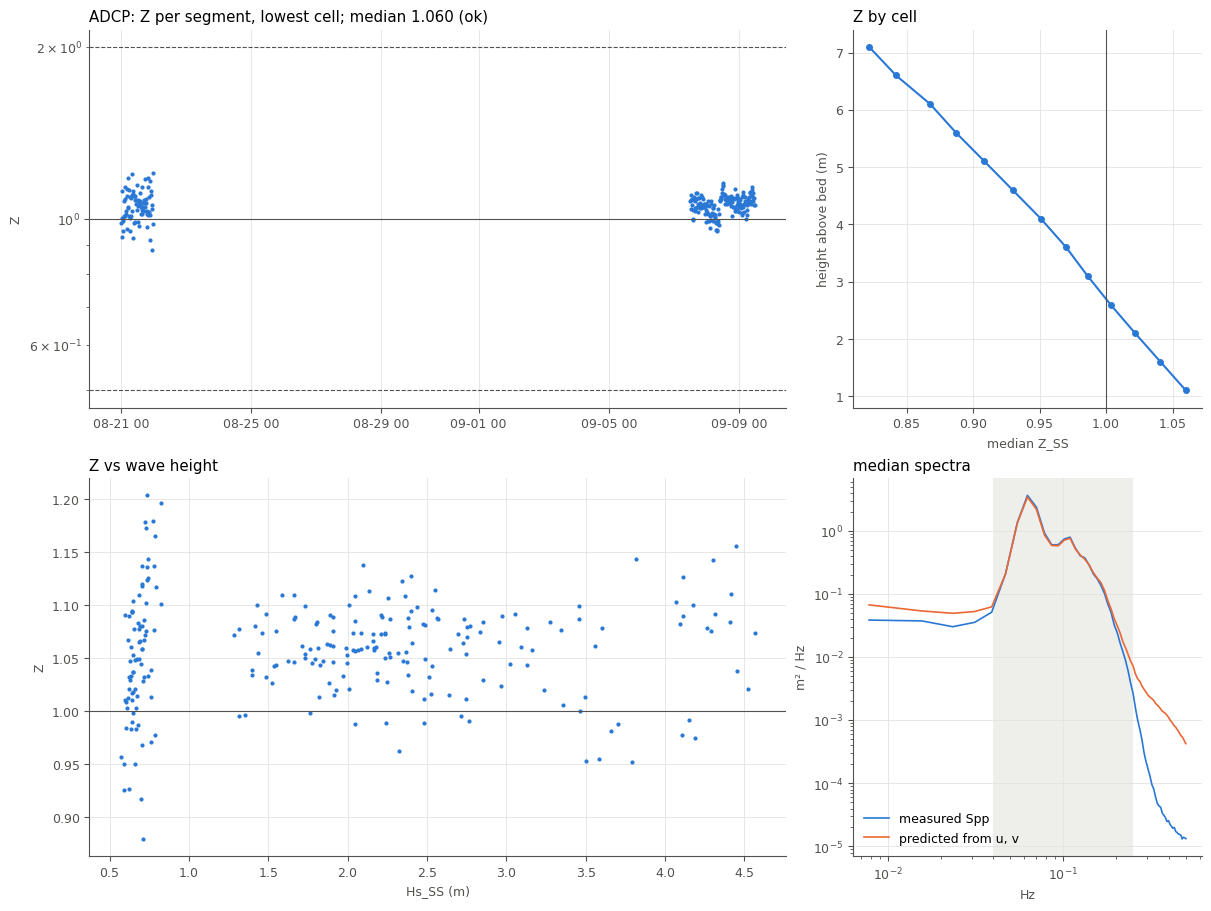

In [17]:
##-----figure: z^2 test-----##
fig = plt.figure(figsize=(12, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 3)
ax = fig.add_subplot(gs[0, :2])
ax.plot(zt.index, Zref, ".", ms=4, color=SERIES)
ax.axhline(1, color=INK2, lw=0.8)
for y in ZT_WINDOW:
    ax.axhline(y, color=INK2, ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_ylabel("z²")
ax.set_title(f"{sensor_id}: z² per hour (Elgar et al. 2005), lowest cell, {ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz; "
             f"median {zmed:.3f} ({z_status})", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
ax = fig.add_subplot(gs[0, 2])
ax.plot([np.nanmedian(zt[f"z2_{c}"]) for c in zt_cells], z[zt_cells], "o-", color=SERIES, ms=4)
ax.axvline(1, color=INK2, lw=0.8)
ax.set_xlabel("median z²")
ax.set_ylabel("height above bed (m)")
ax.set_title("z² by cell", loc="left")
ax = fig.add_subplot(gs[1, :2])
ax.plot(zt.Hs_SS, Zref, ".", ms=4, color=SERIES)
ax.axhline(1, color=INK2, lw=0.8)
ax.set_xlabel("Hs_SS (m)")
ax.set_ylabel("z²")
ax.set_title("z² vs wave height", loc="left")
ax = fig.add_subplot(gs[1, 2])
b = (f_z > 0) & (f_z <= 0.5)
om = 2 * np.pi * f_z[b]
k_med = wavenumber(om, np.median(h_ok))
pred_med = np.median(Suv[:, b], 0) * (om / (GRAV * k_med)) ** 2 * (np.cosh(k_med * Z_P_HAB) / np.cosh(k_med * z[REF_CELL])) ** 2
ax.loglog(f_z[b], np.median(Spp[:, b], 0), color=SERIES, lw=1.2, label="measured Spp")
ax.loglog(f_z[b], pred_med, color="#eb6834", lw=1.2, label="predicted from u, v")
ax.axvspan(*ZT_F_Z2, color=GRID, alpha=0.6, lw=0)
ax.set_xlabel("Hz")
ax.set_ylabel("m² / Hz")
ax.legend(frameon=False, loc="lower left")
ax.set_title(f"median spectra (shaded = z² band)", loc="left")
fig.savefig(fig_dir / f"{sensor_id}_ztest.png", dpi=150)
plt.show()


### 7. Clock check against the co-located VC10
`adv_QC` section 2b left the seconds-level clock check pending the ADCP. The ADCP sits ~3 m west of VC10, and
the waves travel roughly north, so the two should see the same waves at the same time to well under a second.
Both records here are drift-corrected (ADCP −6 s, VC10 +3.571 s).
- Per hour: both pressures on VC10's 2 Hz times, band-passed 0.05–0.3 Hz. The lag with the largest
  cross-correlation (±`SYNC_MAX_LAG`), refined by a parabola through the peak. + = the ADCP sees the waves later.
- A lag that is constant in time is geometry (or an offset set at the start). A lag that trends with time would
  be leftover drift.
- The mean pressure difference is the height difference between the two pressure sensors, in m of water.

ADCP vs VC10: 71 hours; wave-band lag median +0.072 s (IQR +0.051 to +0.077); trend -0.001 s/day
  window 2026-08-21: 23 h, lag median +0.075 s
  window 2026-09-07: 48 h, lag median +0.067 s
  mean pressure ADCP - VC10: -0.531 dbar (~-53 cm: + = ADCP sensor deeper)


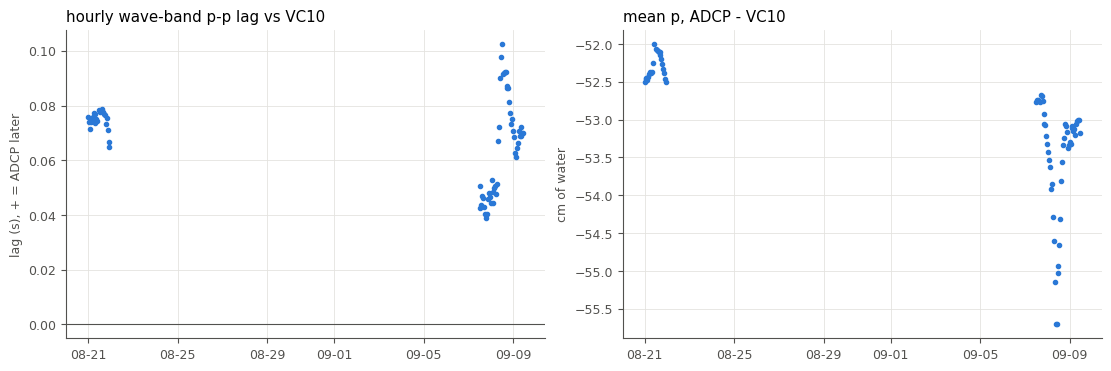

In [18]:
##-----ADCP vs VC10: wave-band lag and mean pressure-----##
vp = vc["p"]

def sync_lag(t_a, p_a, h):
    """Wave-band lag (s, + = ADCP later) and mean pressure difference (dbar) of the ADCP series
    (t_a, p_a) against VC10 over clock hour h. NaN if VC10 has no clean hour there."""
    pv = vp.sel(time=slice(h, h + pd.Timedelta(hours=1) - pd.Timedelta(microseconds=1)))
    if pv.size < 7000 or np.isnan(pv.values).any():
        return np.nan, np.nan
    tv = pv.time.values.astype("int64")
    pa = np.interp(tv, np.asarray(t_a, "datetime64[ns]").astype("int64"), np.asarray(p_a, float))
    fv = np.fft.rfftfreq(pv.size, 0.5)
    band = (fv >= 0.05) & (fv <= 0.3)
    A = np.fft.rfft(pa - pa.mean()); B = np.fft.rfft(pv.values - pv.values.mean())
    A[~band] = 0; B[~band] = 0
    xc = np.fft.irfft(A * np.conj(B), n=pv.size)            # xc[k]: ADCP at t vs VC10 at t - k/2 s
    xc = np.r_[xc[-int(2 * SYNC_MAX_LAG):], xc[:int(2 * SYNC_MAX_LAG) + 1]]
    lg = np.arange(-int(2 * SYNC_MAX_LAG), int(2 * SYNC_MAX_LAG) + 1) * 0.5
    i = np.argmax(xc)
    dl = 0.0 if i in (0, xc.size - 1) else 0.5 * (xc[i - 1] - xc[i + 1]) / (xc[i - 1] - 2 * xc[i] + xc[i + 1])
    return lg[i] + 0.5 * dl, np.nanmean(pa) - float(pv.mean())

rows = []
for h, g in pd.Series(np.arange(tq.size), index=tq).groupby(hour):
    if g.size < seg_n - 8 or brk[g.values[1:]].any():
        continue
    lag, dp = sync_lag(tq.values[g.values], ds.pressure.values[g.values], h)
    if np.isfinite(lag):
        rows.append((h, lag, dp))
sy = pd.DataFrame(rows, columns=["hour", "lag_s", "dp_dbar"]).set_index("hour")
tr = np.polyfit((sy.index - sy.index[0]) / pd.Timedelta(days=1), sy.lag_s, 1)[0] if len(sy) > 2 else np.nan
print(f"{sensor_id} vs {SYNC_SENSOR}: {len(sy)} hours; wave-band lag median {sy.lag_s.median():+.3f} s "
      f"(IQR {sy.lag_s.quantile(.25):+.3f} to {sy.lag_s.quantile(.75):+.3f}); trend {tr:+.3f} s/day")
for a, b in TEST_WINDOWS:
    w = sy[(sy.index >= a) & (sy.index < b)]
    print(f"  window {a[:10]}: {len(w)} h, lag median {w.lag_s.median():+.3f} s")
print(f"  mean pressure ADCP - {SYNC_SENSOR}: {sy.dp_dbar.median():+.3f} dbar "
      f"(~{100 * sy.dp_dbar.median() * 1e4 / (RHO * GRAV):+.0f} cm: + = ADCP sensor deeper)")
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axs[0].plot(sy.index, sy.lag_s, "o", ms=3, color=SERIES)
axs[0].axhline(0, color=INK2, lw=0.8)
axs[0].set_ylabel("lag (s), + = ADCP later")
axs[0].set_title(f"hourly wave-band p-p lag vs {SYNC_SENSOR}", loc="left")
axs[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
axs[1].plot(sy.index, 100 * sy.dp_dbar * 1e4 / (RHO * GRAV), "o", ms=3, color=SERIES)
axs[1].set_ylabel("cm of water")
axs[1].set_title(f"mean p, ADCP - {SYNC_SENSOR}", loc="left")
axs[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_clock_vc10.png", dpi=150)
plt.show()

#### 7b. Lag and wave direction vs VC10 across the whole deployment
The test window only covers two stretches 18 days apart. One hour every `SYNC_EVERY_D` days, from `t_in` to `t_out`,
goes through `load_window → step_pressure → step_beam → step_rotate`. Despiking is skipped: it removed ~0 %.
- *Lag vs elapsed fraction of the raw record.* A lag that grows linearly from ≈ 0 means leftover linear drift, and the
  implied ADCP drift is `drift + slope`: with `drift` = −6 and slope +b s, the clock needs `−6 + b`. A flat lag is an
  offset (timestamp convention, or a clock set with an offset). Nothing is changed automatically: a new value
  goes into `DRIFT_OVERRIDE`, as for VE4. VC10's own measured drift (+3.571 s) is assumed correct.
- *Wave direction ADCP − VC10.* The ADCP compass is steady all deployment (section 5), so a step in this
  difference dates a change in VC10's measured velocity directions. It steps by about −10° between 08-28 and 08-31.
  VC10's own data puts the step at 08-28 18:00–24:00: its wave direction goes from ~343° to ~355° and its w–dp/dt
  coherence drops from ~0.8 to ~0.55 at the same time, while its canister heading, tilt and beam quality don't
  change. The cause (the probe head's orientation relative to the canister?) is not settled: the head was firm at
  recovery.

ADCP vs VC10: 20 of 20 sampled hours usable (189 s)
  lag = +0.042 s +0.000 s x (elapsed fraction of the raw record); residual std 0.021 s
  -> lag +0.04 s at the first sampled hour, +0.04 s at the last
  if the whole trend is ADCP clock drift: drift -5.062 +0.000 = -5.062 s (DRIFT_OVERRIDE candidate; sensor_notes.csv gives '-6')
  mean pressure ADCP - VC10: median -0.528 dbar, range -0.534 to -0.523
  wave direction ADCP - VC10: 17 hours, by sampled hour (deg):
   07-20 -1.1, 07-23 -0.6, 07-26 -0.2, 07-29 -0.4, 08-01 -0.3, 08-04 -0.1, 08-07 +0.3, 08-10 -0.3, 08-13 -0.3, 08-16 -0.7, 08-19 -0.5, 08-28 +0.0, 08-31 -10.2, 09-03 -10.2, 09-06 -10.1, 09-12 -9.6, 09-15 -10.4


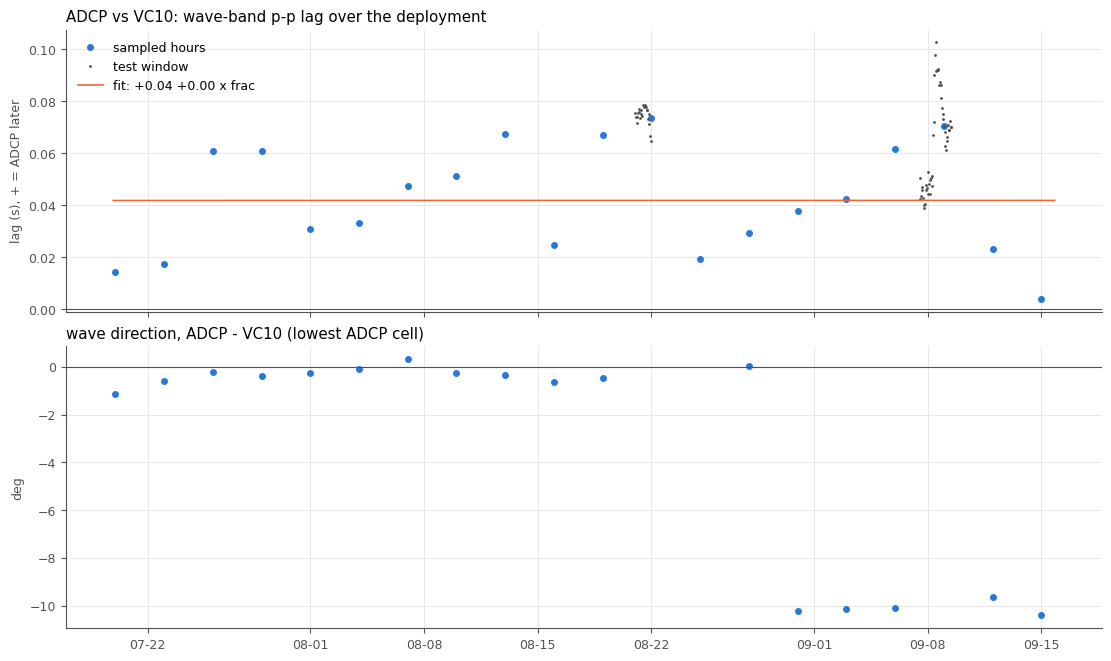

In [19]:
##-----7b. lag + wave direction vs VC10, one hour every SYNC_EVERY_D days-----##
SYNC_EVERY_D = 3

def wave_dir_hour(E, N, p):
    # direction of travel (deg true) from the p-u, p-v co-spectra in 0.05-0.3 Hz. Any NaN left (surface-masked
    # samples) is interpolated here (NaN if > NAN_MAX_FRAC)
    if max(np.isnan(E).mean(), np.isnan(N).mean(), np.isnan(p).mean()) > NAN_MAX_FRAC:
        return np.nan
    E, N, p = (pd.Series(x).interpolate(limit_direction="both").values for x in (E, N, p))
    F = [np.fft.rfft(x - x.mean())[wb] for x in (E, N, p)]
    return np.degrees(np.arctan2(np.real(np.sum(F[0] * np.conj(F[2]))), np.real(np.sum(F[1] * np.conj(F[2]))))) % 360

samp = pd.date_range((t_in + pd.Timedelta(hours=2)).ceil("1h"), t_out - pd.Timedelta(hours=2), freq=f"{SYNC_EVERY_D}D")
vc_dir_all = vc["wave_dir_h"].to_series()
rows = []
t0_ = time.time()
for h in samp:
    d = load_window(h, h + pd.Timedelta(hours=1))
    if d.sizes["time"] < n_use:
        continue
    brk_h = np.r_[False, np.diff(d.time.values) / np.timedelta64(1, "s") > 0.5]
    d = step_rotate(step_replace(step_beam(step_pressure(d)), brk_h))
    p1 = d.pressure.values.astype(float)
    lag, dp = sync_lag(d.time.values, p1, h)
    wd = wave_dir_hour(d.u_east.values[REF_CELL, :n_use].astype(float), d.v_north.values[REF_CELL, :n_use].astype(float),
                       p1[:n_use])
    rows.append((h, lag, dp, wd, vc_dir_all.get(h, np.nan),
                 float((pd.Timestamp(h) - pd.Timestamp(t_raw0)) / (pd.Timestamp(t_raw1) - pd.Timestamp(t_raw0)))))
    del d
rec = pd.DataFrame(rows, columns=["hour", "lag_s", "dp_dbar", "dir_adcp", "dir_vc10", "frac"]).set_index("hour")
rec["ddir"] = (rec.dir_adcp - rec.dir_vc10 + 180) % 360 - 180
ok_l = rec.lag_s.notna()
slope, icpt = np.polyfit(rec.frac[ok_l], rec.lag_s[ok_l], 1)
res = rec.lag_s[ok_l] - (icpt + slope * rec.frac[ok_l])
print(f"{sensor_id} vs {SYNC_SENSOR}: {ok_l.sum()} of {len(samp)} sampled hours usable ({time.time() - t0_:.0f} s)")
print(f"  lag = {icpt:+.3f} s {slope:+.3f} s x (elapsed fraction of the raw record); residual std {res.std():.3f} s")
print(f"  -> lag {icpt + slope * rec.frac[ok_l].min():+.2f} s at the first sampled hour, {icpt + slope * rec.frac[ok_l].max():+.2f} s at the last")
print(f"  if the whole trend is ADCP clock drift: drift {drift:+.3f} {slope:+.3f} = {drift + slope:+.3f} s "
      f"(DRIFT_OVERRIDE candidate; sensor_notes.csv gives '{drift_str}')")
print(f"  mean pressure ADCP - {SYNC_SENSOR}: median {rec.dp_dbar.median():+.3f} dbar, range {rec.dp_dbar.min():+.3f} to {rec.dp_dbar.max():+.3f}")
print(f"  wave direction ADCP - VC10: {rec.ddir.notna().sum()} hours, by sampled hour (deg):")
print("   " + ", ".join(f"{h:%m-%d} {v:+.1f}" for h, v in rec.ddir.dropna().items()))

fig, axs = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, constrained_layout=True)
axs[0].plot(rec.index, rec.lag_s, "o", ms=4, color=SERIES, label="sampled hours")
axs[0].plot(sy.index, sy.lag_s, ".", ms=2, color=INK2, label="test window")
tf = pd.date_range(t_in, t_out, periods=50)
axs[0].plot(tf, icpt + slope * (tf - pd.Timestamp(t_raw0)) / (pd.Timestamp(t_raw1) - pd.Timestamp(t_raw0)),
            color="#eb6834", lw=1.2, label=f"fit: {icpt:+.2f} {slope:+.2f} x frac")
axs[0].axhline(0, color=INK2, lw=0.8)
axs[0].set_ylabel("lag (s), + = ADCP later")
axs[0].legend(frameon=False, loc="upper left")
axs[0].set_title(f"{sensor_id} vs {SYNC_SENSOR}: wave-band p-p lag over the deployment", loc="left")
axs[1].plot(rec.index, rec.ddir, "o", ms=4, color=SERIES)
axs[1].axhline(0, color=INK2, lw=0.8)
axs[1].set_ylabel("deg")
axs[1].set_title(f"wave direction, {sensor_id} - {SYNC_SENSOR} (lowest ADCP cell)", loc="left")
axs[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.savefig(fig_dir / f"{sensor_id}_clock_vc10_record.png", dpi=150)
plt.show()

### 8. Final product (4 Hz, whole deployment)
One netCDF file at the full 4 Hz rate: `data/processed/qc/ADCP_qc.nc`. It is written chunk by chunk
(`CHUNK_H` hours) through the same `step_*` functions, appending along an unlimited `time` dimension.
Open it with `xr.open_dataset(...)`; it loads lazily.

| variable | dims | content |
|---|---|---|
| `u, v, w` | range, time | shore-normal velocity after QC (u onshore, v alongshore, w up), m/s |
| `u_east, v_north` | range, time | true ENU velocity |
| `w_err` | range, time | error velocity (beam-pair difference) |
| `w_b5` | range, time | vertical-beam velocity |
| `amp`, `corr` | beam5, range, time | amplitude (dB) and correlation (%) of beams 1–4 and 5 |
| `qc` | beam5, range, time | flag bits (section 3) |
| `p, p_raw, patm, depth, depth_p, depth_ast, temp, c_sound, heading, pitch, roll, ast_dist, ast_quality` | time | scalars |

Velocities are stored as int16 at 1 mm/s, the instrument's own resolution; amplitude is stored as uint8 at
0.5 dB. Both are lossless. `range` is the height above the bed.
Hourly QC statistics go to `ADCP_qc_hourly.nc` (dims `hour`, `range`), as the Vectors' hourly table:
`pct_surface`, `pct_corr`, `pct_interp`, `pct_runmean`, `pct_snr_low`, `pct_nan_u`, `hs_p`, `seg_runmean_ok`,
`seg_snr_ok` (flag only), the z² test `z2`, `z2_ok` (every cell below the surface ≥ 99 % of the time), `z2_IG`,
`Hs_SS`, `depth_h`, and **`seg_ok` = `seg_runmean_ok` AND `z2_ok`**. `qc` bits: 1 low corr, 2 above the side-lobe
limit, 4 1-s running mean, 8 linear interp, 16 low SNR.
Run the test window first (`ADCP_qc_test.nc`, written below); the full run is off by default.

In [20]:
##-----product builder + netCDF appender-----##
import netCDF4
T_UNITS = "microseconds since 2026-07-01 00:00:00"
VEL_VARS = ["u", "v", "w", "u_east", "v_north", "w_err", "w_b5"]
SCALARS = {"pressure": "p", "pressure_raw": "p_raw", "patm": "patm", "depth": "depth", "depth_p": "depth_p",
           "depth_ast": "depth_ast", "temp": "temp", "c_sound": "c_sound", "heading": "heading", "pitch": "pitch",
           "roll": "roll", "ast_dist": "ast_dist", "ast_quality": "ast_quality"}

def to_product(d):
    # time to whole microseconds (the file's unit; the drift correction leaves sub-microsecond fractions)
    t_us = d.time.values.astype("datetime64[us]").astype("datetime64[ns]")
    out = xr.Dataset(coords={"time": t_us, "range": d.range.values, "beam5": np.arange(1, 6)})
    for v in VEL_VARS:
        out[v] = (("range", "time"), d[v].values, d[v].attrs)
    out["amp"] = (("beam5", "range", "time"), np.concatenate([d["amp"].values, d["amp_b5"].values[None]]).astype("float32"),
                  {"units": "dB", "long_name": "echo amplitude, beams 1-4 slant, 5 vertical"})
    out["corr"] = (("beam5", "range", "time"), np.concatenate([d["corr"].values, d["corr_b5"].values[None]]).astype("uint8"),
                   {"units": "%", "long_name": "beam correlation, beams 1-4 slant, 5 vertical"})
    # raw values, not the DataArray: its time coordinate is not rounded, and xarray would align on it
    out["qc"] = (("beam5", "range", "time"), d["qc"].values.astype("uint8"), d["qc"].attrs)
    for a, b in SCALARS.items():
        out[b] = ("time", d[a].values.astype("float32"), d[a].attrs)
    out["heading"] = out["heading"] % 360
    out["heading"].attrs.update(units="degree", long_name="heading, true (declination applied)")
    out["range"].attrs.update(units="m", long_name="cell centre height above the bed (H_DEPLOY + range from transducer)")
    keep = ["inst_model", "SerialNum", "fs", "cell_size", "blank_dist", "beam_angle", "nominal_corr", "h_deploy",
            "b5_lead_s"] + [k for k in d.attrs if k.startswith(("qc_", "rot_"))]
    out.attrs = {k: d.attrs[k] for k in keep if k in d.attrs}
    out.attrs.update({"sensor_id": sensor_id, "qc_clock_drift_s": drift,
                      "qc_clock_drift_convention": "+ = sensor clock fast; t_true = t - drift * frac_elapsed",
                      "qc_clock_raw_start": str(t_raw0), "qc_clock_raw_end": str(t_raw1),
                      "qc_trim_t_in": str(t_in), "qc_trim_t_out": str(t_out), "qc_clock_tide_lag_min": tide_lag_min,
                      "qc_notebook": "processing/adcp_QC.ipynb"})
    for k, v in list(out.attrs.items()):
        if isinstance(v, (bool, list, dict)):
            out.attrs[k] = str(v)
    return out

def encoding(prod):
    nr = prod.sizes["range"]
    enc = {"time": {"dtype": "int64", "units": T_UNITS, "calendar": "standard", "chunksizes": (14400,)}}
    for v in prod.data_vars:
        dims = prod[v].dims
        cs = tuple({"time": 14400, "range": nr, "beam5": 1}[x] for x in dims)
        enc[v] = {"zlib": True, "complevel": 4, "chunksizes": cs}
    for v in VEL_VARS:
        enc[v].update(dtype="int16", scale_factor=0.001, _FillValue=np.int16(-32768))
    enc["amp"].update(dtype="uint8", scale_factor=0.5, _FillValue=np.uint8(255))
    return enc

def write_product(prod, path, first):
    if first:
        prod.to_netcdf(path, unlimited_dims=["time"], encoding=encoding(prod))
        return
    with netCDF4.Dataset(path, "a") as nc:
        n0 = nc.dimensions["time"].size
        n = prod.sizes["time"]
        t64 = (prod.time.values - np.datetime64("2026-07-01T00:00:00")) // np.timedelta64(1, "us")
        assert t64[0] > nc.variables["time"][n0 - 1], "chunks must be appended in time order"
        nc.variables["time"][n0:n0 + n] = t64
        for v in prod.data_vars:
            a = prod[v].values
            if a.dtype.kind == "f":
                a = np.ma.masked_invalid(a)
            nc.variables[v][..., n0:n0 + n] = a        # time is the last dimension of every variable

def hourly_stats(d, brk):
    """Per clock hour and cell, as the Vectors' hourly table: % of each flag (below-surface samples), Hs_p, the
    z^2 test (Elgar et al. 2005) and seg_ok = seg_runmean_ok & z2_ok."""
    tt = pd.DatetimeIndex(d.time.values)
    hr = tt.floor("1h")
    qc_ = d["qc"].values
    sub = ~((qc_[0] & QC_SURF) > 0)
    nb = pd.DataFrame(sub.T, index=tt).groupby(hr).sum().clip(lower=1)
    pct = lambda m: (100 * pd.DataFrame((m & sub).T, index=tt).groupby(hr).sum() / nb).values
    ps = pd.Series(d["pressure"].values.astype(float), index=tt)
    php = ps - ps.rolling(int(300 * fs), center=True, min_periods=int(60 * fs)).mean()
    hs = (4 * php.groupby(hr).std() * 1e4 / (RHO * GRAV)).values
    hours = np.unique(hr.values)
    out = xr.Dataset(
        {"pct_surface": (("hour", "range"), (100 * pd.DataFrame((~sub).T, index=tt).groupby(hr).mean()).values),
         "pct_corr": (("hour", "range"), pct(((qc_[:4] & QC_CORR) > 0).any(0))),
         "pct_interp": (("hour", "range"), pct(((qc_[:4] & QC_INTERP) > 0).any(0))),
         "pct_runmean": (("hour", "range"), pct(((qc_[:4] & QC_RUNMEAN) > 0).any(0))),
         "pct_snr_low": (("hour", "range"), pct(((qc_[:4] & QC_SNR) > 0).any(0))),
         "pct_nan_u": (("hour", "range"), pct(np.isnan(d["u"].values))),
         "hs_p": ("hour", hs)},
        coords={"hour": hours, "range": d.range.values})
    out["seg_runmean_ok"] = out["pct_runmean"] <= 100 * RUNMEAN_MAX_FRAC
    out["seg_snr_ok"] = out["pct_snr_low"] <= 100 * SNR_RUN_FRAC
    out["seg_snr_ok"].attrs["comment"] = "Elgar et al. 2005 run-rejection rule; diagnostic, NOT applied to seg_ok"
    zt_h = ztest_hours(d, zt_cells)[0].reindex(pd.DatetimeIndex(hours))
    z2 = np.full((hours.size, d.sizes["range"]), np.nan)
    for c in zt_cells:
        z2[:, c] = zt_h[f"z2_{c}"].values
    out["z2"] = (("hour", "range"), z2, {"long_name": f"z^2, measured / velocity-predicted pressure variance, "
                                         f"{ZT_F_Z2[0]}-{ZT_F_Z2[1]} Hz (Elgar et al. 2005 Eq. 1)"})
    out["z2_ok"] = (out["z2"] > ZT_WINDOW[0]) & (out["z2"] < ZT_WINDOW[1])          # no z^2 -> False
    out["z2_IG"] = ("hour", zt_h["z2_IG"].values, {"long_name": "z^2 over the IG band, lowest cell, diagnostic"})
    out["Hs_SS"] = ("hour", zt_h["Hs_SS"].values, {"units": "m", "long_name": f"Hs from p, {ZT_F_SS[0]}-{ZT_F_SS[1]} Hz"})
    out["depth_h"] = ("hour", zt_h["h"].values, {"units": "m", "long_name": "mean p (m) + Z_P_HAB"})
    out["seg_ok"] = out["seg_runmean_ok"] & out["z2_ok"]
    out["seg_ok"].attrs["long_name"] = (f"good (hour, cell): running mean <= {100 * RUNMEAN_MAX_FRAC:g} % AND "
                                        f"{ZT_WINDOW[0]} < z^2 < {ZT_WINDOW[1]}")
    out.attrs.update({"zt_method": "Elgar, Raubenheimer & Guza 2005 (Meas. Sci. Technol. 16), section 3.3",
                      "zt_band_z2_hz": str(list(ZT_F_Z2)), "zt_window": str(list(ZT_WINDOW)), "zt_z_p_m": Z_P_HAB,
                      "zt_segment": "1 h, clock-aligned", "zt_welch_nfft": ZT_NFFT,
                      "zt_cells_height_m": ", ".join(f"{z[c]:.2f}" for c in zt_cells)})
    return out

##-----test product: the test window through the product writer-----##
test_path = qc_dir / f"{sensor_id}_qc_test.nc"
test_path.unlink(missing_ok=True)
prod = to_product(ds)
for j, (a, b) in enumerate(TEST_WINDOWS):
    write_product(prod.sel(time=slice(a, b)), test_path, first=(j == 0))
chk = xr.open_dataset(test_path)
err = float(np.nanmax(np.abs(chk.u.values - prod.u.values)))
assert (chk.time.values == prod.time.values).all()
assert chk.qc.dtype == np.uint8 and (chk.qc.values == prod.qc.values).all() and (prod.qc.values == ds.qc.values).all(), \
    "qc flags did not survive the product round trip"
print(f"saved {test_path} ({test_path.stat().st_size / 1e6:.0f} MB for {prod.sizes['time']:,} pings; "
      f"~{test_path.stat().st_size / prod.sizes['time'] * (t_out - t_in).total_seconds() * fs / 1e9:.1f} GB "
      f"expected for the deployment); round-trip max |du| {err * 1000:.2f} mm/s, "
      f"NaN pattern kept: {bool((np.isnan(chk.u.values) == np.isnan(prod.u.values)).all())}")
chk.close()
del prod
gc.collect();
# hourly table for the test window (same function the full run uses)
hs_test = hourly_stats(ds, brk)
so = hs_test.seg_ok.values[:, zt_cells]
print(f"hourly table, test window: seg_ok in {100 * so.mean():.1f} % of tested (hour, cell); lowest cell "
      f"{int(hs_test.seg_ok.values[:, REF_CELL].sum())} of {hs_test.sizes['hour']} hours "
      f"(running-mean fails {int((~hs_test.seg_runmean_ok.values[:, REF_CELL]).sum())}, "
      f"z^2 fails or missing {int((~hs_test.z2_ok.values[:, REF_CELL]).sum())}); "
      f"seg_snr_ok fails at the lowest cell {int((~hs_test.seg_snr_ok.values[:, REF_CELL]).sum())} hours (flag only)")


saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/data/processed/qc/ADCP_qc_test.nc (278 MB for 1,036,765 pings; ~5.4 GB expected for the deployment); round-trip max |du| 0.50 mm/s, NaN pattern kept: True


### Run the whole deployment
Off by default. Once the test window checks out:
1. set `RUN_FULL = True` in the cell below and run it on its own (≈ 1 h; ~0.3 GB RAM per 24-h chunk, ~5.3 GB on disk),
2. it goes through `t_in → t_out` in `CHUNK_H`-hour chunks: `load_window → step_pressure → step_beam → step_replace →
   step_rotate`, appending to `ADCP_qc.nc`. Each chunk is read with a 5-min overlap on either side, trimmed
   after QC, so the running means and interpolations don't see an artificial edge,
3. the hourly table (flags, z², `seg_ok`) is saved at the end to `ADCP_qc_hourly.nc`.

If it stops partway, delete `ADCP_qc.nc` and rerun. Chunks must be appended in order.

In [21]:
##-----full run: whole deployment, chunk by chunk-----##
RUN_FULL = False

if RUN_FULL:
    del ds
    gc.collect()
    final_path = qc_dir / f"{sensor_id}_qc.nc"
    assert not final_path.exists(), f"{final_path} exists; delete it to rerun"
    pad = pd.Timedelta(minutes=5)
    edges = pd.date_range(t_in.ceil("1h"), t_out, freq=f"{CHUNK_H}h")
    edges = [t_in] + [e for e in edges if e > t_in] + [t_out]
    hstats = []
    t_start = time.time()
    for j, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        t0_ = time.time()
        d = load_window(max(a - pad, t_in), min(b + pad, t_out))
        tt = pd.DatetimeIndex(d.time.values)
        brk_d = np.r_[False, np.diff(d.time.values) / np.timedelta64(1, "s") > 0.5]
        d = step_pressure(d)
        d = step_beam(d)
        d = step_replace(d, brk_d)
        d = step_rotate(d)
        core = (tt >= a) & (tt < b) if b < t_out else (tt >= a) & (tt <= b)
        d = d.isel(time=core)
        brk_c = brk_d[core]
        write_product(to_product(d), final_path, first=(j == 0))
        hstats.append(hourly_stats(d, brk_c))
        print(f"{a:%m-%d %H:%M} -> {b:%m-%d %H:%M}: {d.sizes['time']:,} pings in {time.time() - t0_:.0f} s "
              f"(total {(time.time() - t_start) / 60:.0f} min, file {final_path.stat().st_size / 1e9:.2f} GB)", flush=True)
        del d
        gc.collect()
    hs_all = xr.concat(hstats, dim="hour")
    hs_all.to_netcdf(qc_dir / f"{sensor_id}_qc_hourly.nc")
    print(f"done in {(time.time() - t_start) / 3600:.1f} h: {final_path} ({final_path.stat().st_size / 1e9:.2f} GB); "
          f"record median z^2 (lowest cell) {float(hs_all.z2.isel(range=REF_CELL).median()):.3f}; "
          f"seg_ok at the lowest cell {100 * float(hs_all.seg_ok.isel(range=REF_CELL).mean()):.1f} % of hours")

#### z² test over the whole deployment
From `ADCP_qc_hourly.nc`, written by the full run: z² per hour at the lowest cell, the daily median z² by cell, wave
height, z² against wave height, and the median z² profile. Saved as `figs/qc/ADCP_ztest_full.png`.


#### ADCP vs the co-located VC10, whole deployment
Pressure and velocity of the ADCP's lowest cell against VC10 (both drift-corrected, both in the transect C shore-normal frame): hourly statistics over the whole record, then 3-min series and 1-h spectra for the largest-swell hour and the calmest hour. Saved as `figs/qc/ADCP_VC10_compare.png`.

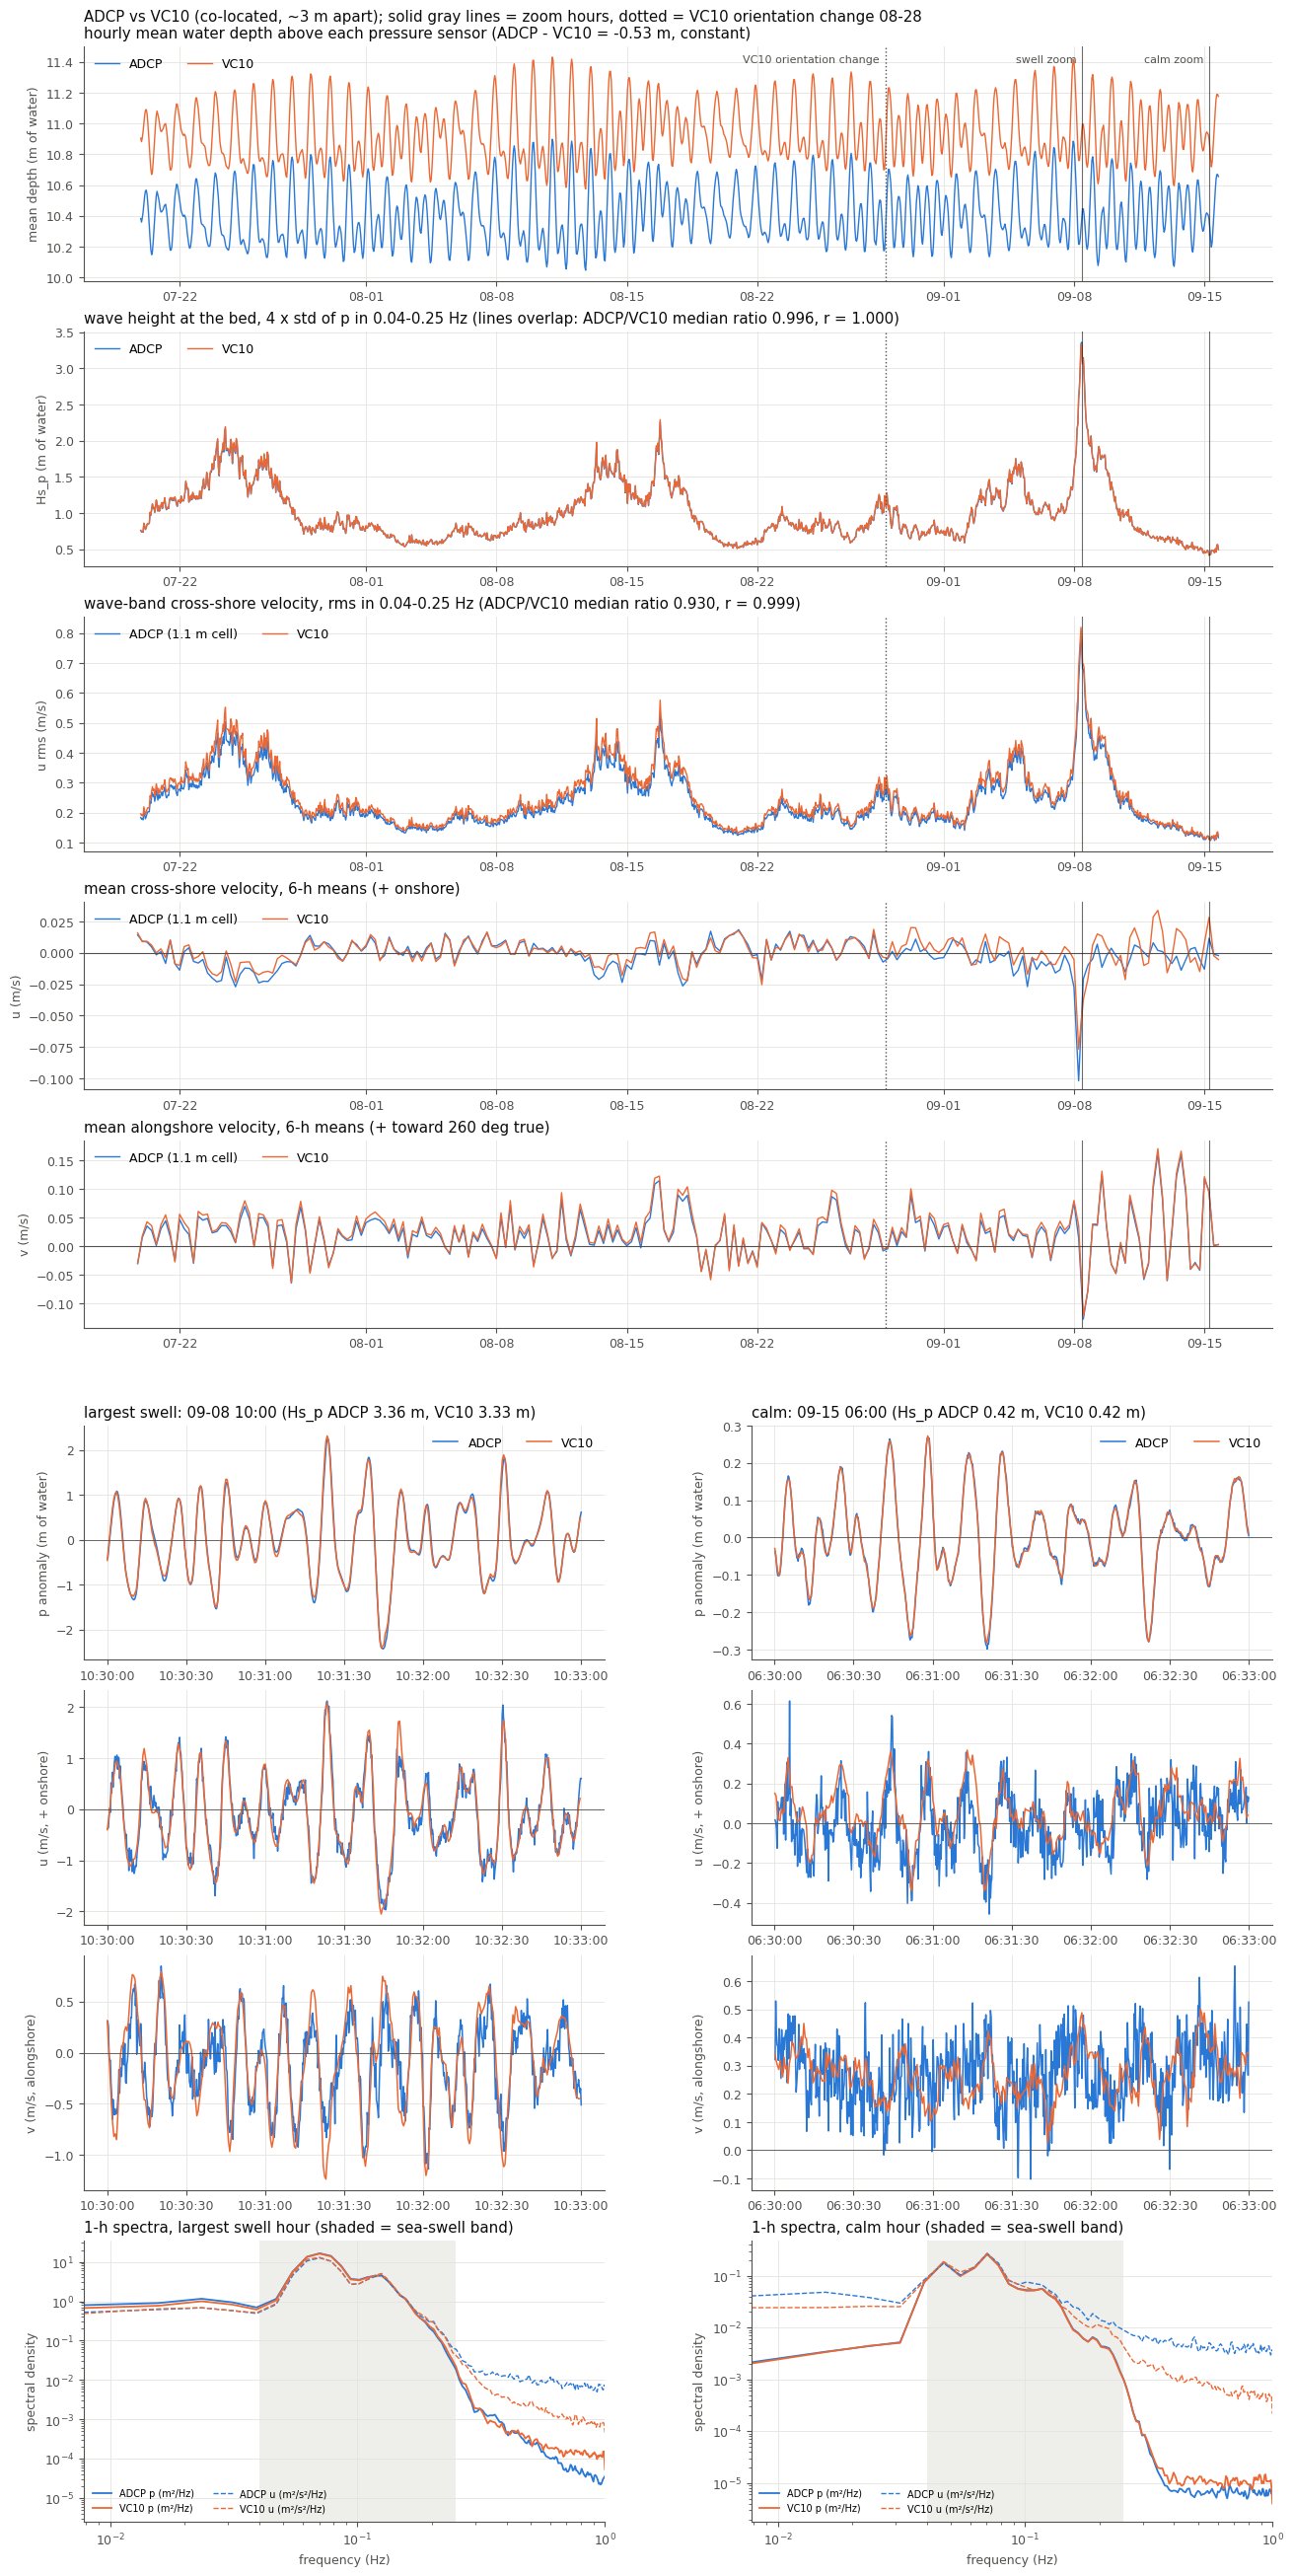

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/figs/qc/ADCP_VC10_compare.png; 1381 common hours; zoom hours: swell 2026-09-08 10:00:00, calm 2026-09-15 06:00:00
  all               : depth ADCP - VC10 -0.527 m | Hs_p ratio 0.996 (r 1.000) | u rms ratio 0.930 (r 0.999) | mean u -0.2 vs +0.1 cm/s (r 0.85) | mean v +2.1 vs +2.6 cm/s (r 1.00)
  before 08-28 21:00: depth ADCP - VC10 -0.527 m | Hs_p ratio 0.996 (r 1.000) | u rms ratio 0.927 (r 1.000) | mean u -0.0 vs +0.1 cm/s (r 0.95) | mean v +2.0 vs +2.5 cm/s (r 1.00)
  after             : depth ADCP - VC10 -0.527 m | Hs_p ratio 0.997 (r 1.000) | u rms ratio 0.941 (r 0.999) | mean u -0.5 vs +0.1 cm/s (r 0.76) | mean v +2.3 vs +2.8 cm/s (r 1.00)


In [22]:
##-----figure: ADCP vs the co-located VC10, pressure and velocity-----##
# ADCP: lowest cell (REF_CELL) of ADCP_qc.nc, 4 Hz. VC10: VC10_QC.nc, 2 Hz. Both are drift-corrected and in the
# same shore-normal frame (transect C, 350 deg true): u onshore, v alongshore.
from scipy.signal import welch
C_ADCP, C_VC = "#2a78d6", "#eb6834"                  # identity colors (validated pair)
M_WATER = 1e4 / (RHO * GRAV)                          # dbar -> m of water
F_WAVE = (0.04, 0.25)                                 # Hz, sea-swell band (as the Z-test)
VC10_CHANGE = pd.Timestamp("2026-08-28 21:00")         # VC10 wave direction +12 deg, w coherence 0.8 -> 0.55 (7b)

prod_path = qc_dir / f"{sensor_id}_qc.nc"
if prod_path.exists():
    A = xr.open_dataset(prod_path)
    a_t = A.time.values
    a_p = A.p.values.astype(float)
    a_u = A.u.isel(range=REF_CELL).values.astype(float)
    a_v = A.v.isel(range=REF_CELL).values.astype(float)
    z_a = float(A.range.values[REF_CELL])
    V = xr.open_dataset(qc_dir / f"{SYNC_SENSOR}_QC.nc")
    V = V.sel(time=slice(a_t[0], a_t[-1]))
    v_t = V.time.values
    v_p, v_u, v_v = (V[k].values.astype(float) for k in ("p", "u", "v"))

    def hourly(t, p, u, v, fs_):
        """Per clock hour: mean depth (m of water), wave-band Hs_p = 4 std (m of water), wave-band u rms, mean u, v."""
        tt = pd.DatetimeIndex(t)
        rows = []
        for h, g in pd.Series(np.arange(tt.size), index=tt).groupby(tt.floor("1h")):
            ii = g.values
            if ii.size < 0.9 * 3600 * fs_:
                continue
            f_ = np.fft.rfftfreq(ii.size, 1 / fs_)
            band = (f_ >= F_WAVE[0]) & (f_ <= F_WAVE[1])
            out = {"hour": h, "depth": np.nanmean(p[ii]) * M_WATER, "u": np.nanmean(u[ii]), "v": np.nanmean(v[ii])}
            for k, x in (("hs", p[ii] * M_WATER), ("urms", u[ii])):
                if np.isnan(x).mean() > NAN_MAX_FRAC:
                    out[k] = np.nan
                    continue
                x = pd.Series(x).interpolate(limit_direction="both").values
                X = np.fft.rfft(x - x.mean())
                X[~band] = 0
                sd = np.std(np.fft.irfft(X, n=x.size))
                out[k] = 4 * sd if k == "hs" else sd
            rows.append(out)
        return pd.DataFrame(rows).set_index("hour")

    ha = hourly(a_t, a_p, a_u, a_v, fs)
    hv = hourly(v_t, v_p, v_u, v_v, 2.0)
    hh = ha.join(hv, lsuffix="_a", rsuffix="_v", how="inner")

    # zoom hours: largest swell and the calmest hour (by ADCP Hs_p), each with both instruments complete
    ok_h = hh.dropna()
    h_big = ok_h.hs_a.idxmax()
    h_calm = ok_h.hs_a.idxmin()

    def window(t, x, a, b):
        m = (t >= np.datetime64(a)) & (t < np.datetime64(b))
        return t[m], x[m]

    def spec(t, x, h, fs_, scale=1.0):
        tt, xx = window(t, x, h, h + pd.Timedelta(hours=1))
        xx = pd.Series(xx * scale).interpolate(limit_direction="both").values
        return welch(xx - xx.mean(), fs=fs_, window="hann", nperseg=int(128 * fs_), noverlap=int(64 * fs_))

    d_ = hh.dropna()
    h6 = hh[["u_a", "u_v", "v_a", "v_v"]].resample("6h").mean()
    fig = plt.figure(figsize=(13, 26), constrained_layout=True)
    gs = fig.add_gridspec(10, 2, height_ratios=[1, 1, 1, 0.8, 0.8, 0.2, 1, 1, 1, 1.2])
    series = [("depth", "mean depth (m of water)",
               f"hourly mean water depth above each pressure sensor (ADCP - {SYNC_SENSOR} = {np.median(d_.depth_a - d_.depth_v):+.2f} m, constant)"),
              ("hs", "Hs_p (m of water)",
               f"wave height at the bed, 4 x std of p in {F_WAVE[0]}-{F_WAVE[1]} Hz (lines overlap: ADCP/{SYNC_SENSOR} "
               f"median ratio {np.median(d_.hs_a / d_.hs_v):.3f}, r = {np.corrcoef(d_.hs_a, d_.hs_v)[0, 1]:.3f})"),
              ("urms", "u rms (m/s)",
               f"wave-band cross-shore velocity, rms in {F_WAVE[0]}-{F_WAVE[1]} Hz (ADCP/{SYNC_SENSOR} median ratio "
               f"{np.median(d_.urms_a / d_.urms_v):.3f}, r = {np.corrcoef(d_.urms_a, d_.urms_v)[0, 1]:.3f})"),
              ("u", "u (m/s)", "mean cross-shore velocity, 6-h means (+ onshore)"),
              ("v", "v (m/s)", "mean alongshore velocity, 6-h means (+ toward 260 deg true)")]
    ax0 = None
    for r, (k, ylab, ttl) in enumerate(series):
        ax = fig.add_subplot(gs[r, :], sharex=ax0)
        ax0 = ax0 or ax
        src = h6 if k in ("u", "v") else hh
        ax.plot(src.index, src[f"{k}_a"], color=C_ADCP, lw=1.0, label=f"ADCP ({z_a:.1f} m cell)" if k != "depth" and k != "hs" else "ADCP")
        ax.plot(src.index, src[f"{k}_v"], color=C_VC, lw=1.0, label=SYNC_SENSOR)
        if k in ("u", "v"):
            ax.axhline(0, color=INK2, lw=0.8)
        ax.legend(frameon=False, loc="upper left", ncol=2)
        for h in (h_big, h_calm):
            ax.axvline(h + pd.Timedelta(minutes=30), color=INK, lw=0.8, alpha=0.6)
        ax.axvline(VC10_CHANGE, color=INK2, ls=":", lw=1)
        ax.set_ylabel(ylab)
        ax.set_title(ttl, loc="left", color=INK)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        if r == 0:
            for x, lab in [(VC10_CHANGE, f"{SYNC_SENSOR} orientation change"), (h_big, "swell zoom"), (h_calm, "calm zoom")]:
                ax.annotate(lab, (x, 1), xycoords=("data", "axes fraction"), xytext=(-4, -12), textcoords="offset points",
                            color=INK2, fontsize=8, ha="right")
            ax.set_title(f"{sensor_id} vs {SYNC_SENSOR} (co-located, ~3 m apart); solid gray lines = zoom hours, dotted = "
                         f"{SYNC_SENSOR} orientation change 08-28\n{ttl}", loc="left", color=INK)

    # zooms: left = largest swell, right = calmest hour; 3 min from the middle of the hour
    for j, (h, lab) in enumerate([(h_big, "largest swell"), (h_calm, "calm")]):
        a0 = h + pd.Timedelta(minutes=30); a1 = a0 + pd.Timedelta(minutes=3)
        hdr = f"{lab}: {h:%m-%d %H}:00 (Hs_p ADCP {hh.hs_a[h]:.2f} m, {SYNC_SENSOR} {hh.hs_v[h]:.2f} m)"
        for r, (xa, xv, ylab, scale) in enumerate([(a_p, v_p, "p anomaly (m of water)", M_WATER),
                                                   (a_u, v_u, "u (m/s, + onshore)", 1.0),
                                                   (a_v, v_v, "v (m/s, alongshore)", 1.0)]):
            ax = fig.add_subplot(gs[6 + r, j])
            ta, ya = window(a_t, xa * scale, a0, a1)
            tv, yv = window(v_t, xv * scale, a0, a1)
            if r == 0:
                ya, yv = ya - np.nanmean(ya), yv - np.nanmean(yv)
            ax.plot(ta, ya, color=C_ADCP, lw=1.1, label=f"ADCP ({z_a:.1f} m)" if r else "ADCP")
            ax.plot(tv, yv, color=C_VC, lw=1.1, label=SYNC_SENSOR)
            ax.axhline(0, color=INK2, lw=0.6)
            ax.set_ylabel(ylab)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
            ax.set_title(hdr if r == 0 else "", loc="left", color=INK)
            if r == 0:
                ax.legend(frameon=False, loc="upper right", ncol=2)
        # spectra over the whole hour
        ax = fig.add_subplot(gs[9, j])
        for t_, x_, fs_, col, name in [(a_t, a_p, fs, C_ADCP, "ADCP"), (v_t, v_p, 2.0, C_VC, SYNC_SENSOR)]:
            f_, S = spec(t_, x_, h, fs_, M_WATER)
            ax.loglog(f_[1:], S[1:], color=col, lw=1.3, label=f"{name} p (m²/Hz)")
        for t_, x_, fs_, col, name in [(a_t, a_u, fs, C_ADCP, "ADCP"), (v_t, v_u, 2.0, C_VC, SYNC_SENSOR)]:
            f_, S = spec(t_, x_, h, fs_)
            ax.loglog(f_[1:], S[1:], color=col, lw=1.0, ls="--", label=f"{name} u (m²/s²/Hz)")
        ax.axvspan(*F_WAVE, color=GRID, alpha=0.6, lw=0)
        ax.set_xlim(1 / 128, 1.0)
        ax.set_xlabel("frequency (Hz)")
        ax.set_ylabel("spectral density")
        ax.set_title(f"1-h spectra, {lab} hour (shaded = sea-swell band)", loc="left", color=INK)
        ax.legend(frameon=False, loc="lower left", fontsize=7, ncol=2)
    fig.savefig(fig_dir / f"{sensor_id}_{SYNC_SENSOR}_compare.png", dpi=150)
    plt.show()

    # agreement numbers, before / after the VC10 orientation change
    print(f"saved {fig_dir / f'{sensor_id}_{SYNC_SENSOR}_compare.png'}; {len(hh)} common hours; "
          f"zoom hours: swell {h_big}, calm {h_calm}")
    for lab, m in [("all", np.ones(len(hh), bool)), ("before 08-28 21:00", hh.index < VC10_CHANGE),
                   ("after", hh.index >= VC10_CHANGE)]:
        d = hh[m].dropna()
        print(f"  {lab:18s}: depth ADCP - {SYNC_SENSOR} {np.median(d.depth_a - d.depth_v):+.3f} m | Hs_p ratio "
              f"{np.median(d.hs_a / d.hs_v):.3f} (r {np.corrcoef(d.hs_a, d.hs_v)[0, 1]:.3f}) | u rms ratio "
              f"{np.median(d.urms_a / d.urms_v):.3f} (r {np.corrcoef(d.urms_a, d.urms_v)[0, 1]:.3f}) | mean u "
              f"{100 * d.u_a.mean():+.1f} vs {100 * d.u_v.mean():+.1f} cm/s (r {np.corrcoef(d.u_a, d.u_v)[0, 1]:.2f}) | "
              f"mean v {100 * d.v_a.mean():+.1f} vs {100 * d.v_v.mean():+.1f} cm/s (r {np.corrcoef(d.v_a, d.v_v)[0, 1]:.2f})")
    A.close(); V.close()
else:
    print(f"{prod_path} not found: run the full deployment first (RUN_FULL)")


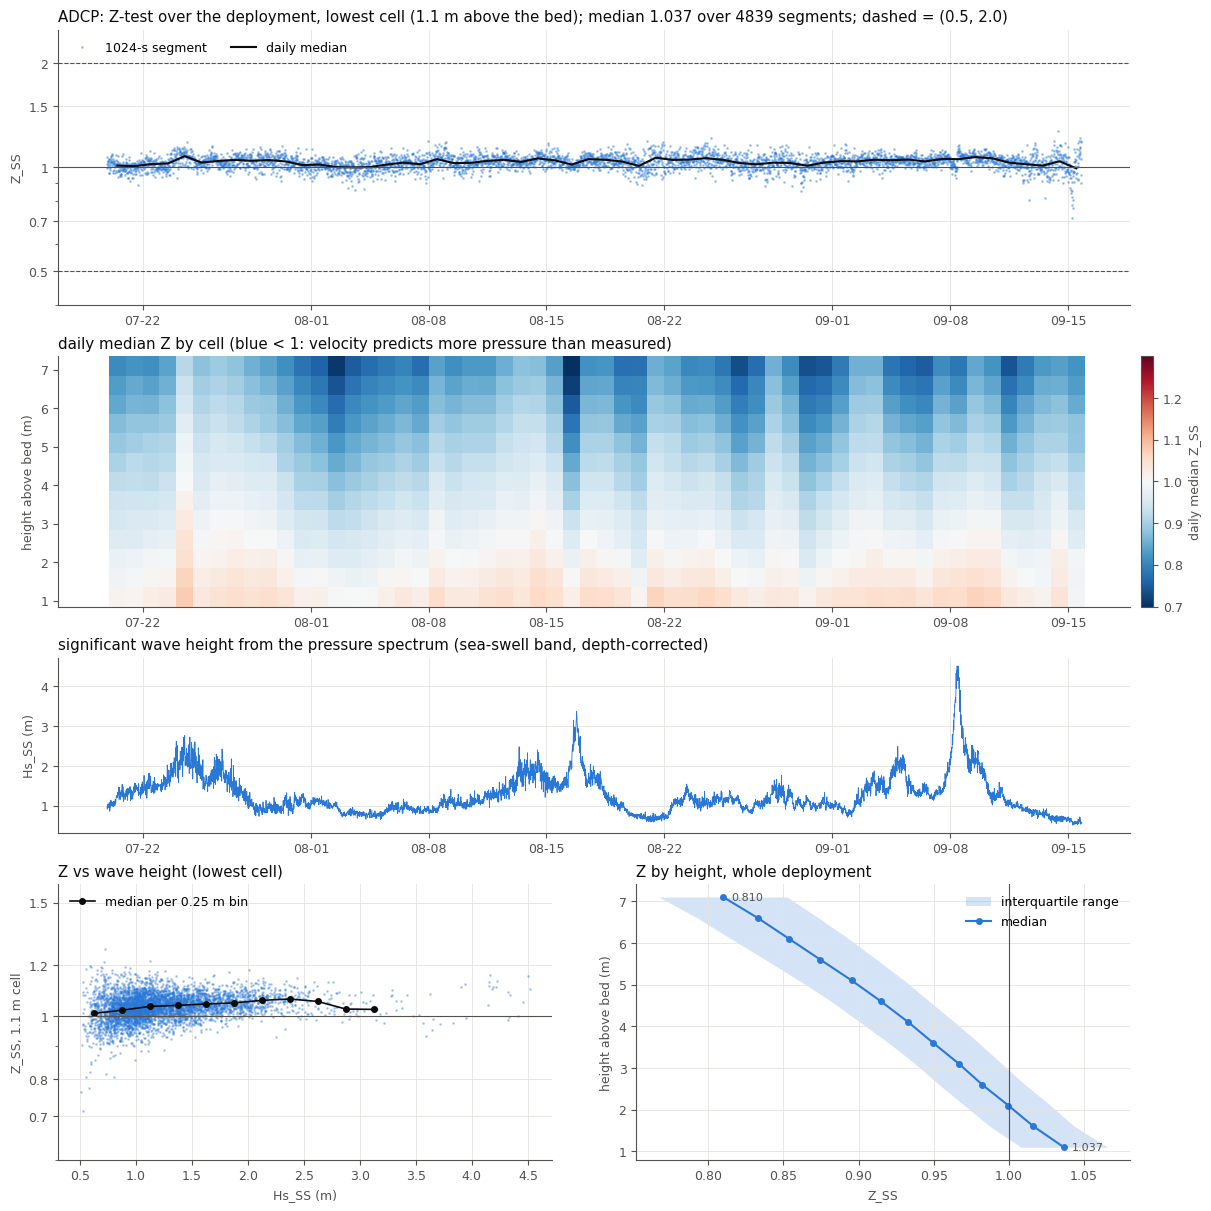

saved /Users/isidorarojas/Desktop/DIRECTORY/2026/4EWA/figs/qc/ADCP_ztest_full.png
lowest cell: median 1.037, 5-95 % 0.956-1.110, outside (0.5, 2.0) in 0.00 % of segments
median Z by height: 1.1 m 1.037, 1.6 m 1.016, 2.1 m 1.000, 2.6 m 0.982, 3.1 m 0.967, 3.6 m 0.950, 4.1 m 0.933, 4.6 m 0.915, 5.1 m 0.895, 5.6 m 0.874, 6.1 m 0.854, 6.6 m 0.833, 7.1 m 0.810


In [23]:
##-----figure: z^2 test over the whole deployment (from ADCP_qc_hourly.nc, written by the full run)-----##
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import NullFormatter
zf_path = qc_dir / f"{sensor_id}_qc_hourly.nc"
zf = xr.open_dataset(zf_path) if zf_path.exists() else None
if zf is not None and "z2" in zf:
    tested = np.flatnonzero(zf["z2"].notnull().any("hour").values)
    zc = zf.range.values[tested]
    cols = [f"{h:.2f}" for h in zc]
    Zs = pd.DataFrame(zf["z2"].values[:, tested], index=pd.DatetimeIndex(zf.hour.values), columns=cols)
    Z0 = Zs[cols[0]]
    Hs = zf["Hs_SS"].to_series()
    day = Zs.resample("1D").median()
    n_day = Z0.resample("1D").count()
    day[n_day < 6] = np.nan                              # < 6 h of valid hours -> blank
    zmed_all = float(np.nanmedian(Z0))

    fig = plt.figure(figsize=(12, 12), constrained_layout=True)
    gs = fig.add_gridspec(4, 2, height_ratios=[1.1, 1.0, 0.7, 1.1])
    # A: lowest cell, every segment + daily median
    ax = fig.add_subplot(gs[0, :])
    ax.plot(Z0.index, Z0.values, ".", ms=2, color=SERIES, alpha=0.35, lw=0, label="1-h segment")
    ax.plot(day.index + pd.Timedelta(hours=12), day[cols[0]], color=INK, lw=1.5, label="daily median")
    ax.axhline(1, color=INK2, lw=0.8)
    for y in ZT_WINDOW:
        ax.axhline(y, color=INK2, ls="--", lw=0.8)
    ax.set_yscale("log")
    ax.set_ylim(0.4, 2.5)
    ax.set_yticks([0.5, 0.7, 1, 1.5, 2])
    ax.set_yticklabels(["0.5", "0.7", "1", "1.5", "2"])
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_ylabel("z²")
    ax.legend(frameon=False, loc="upper left", ncol=2)
    ax.set_title(f"{sensor_id}: z² test (Elgar et al. 2005) over the deployment, lowest cell ({zc[0]:.1f} m above the bed); "
                 f"median {zmed_all:.3f} over {int(Z0.notna().sum())} hours; dashed = {ZT_WINDOW}",
                 loc="left", color=INK)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    xl = ax.get_xlim()
    # B: daily median Z by height (diverging about Z = 1)
    ax = fig.add_subplot(gs[1, :], sharex=ax)
    dn = mdates.date2num(day.index + pd.Timedelta(hours=12))
    im = ax.pcolormesh(dn, zc, day[cols].values.T, shading="nearest", cmap="RdBu_r",
                       norm=TwoSlopeNorm(vcenter=1.0, vmin=0.7, vmax=1.3))
    plt.colorbar(im, ax=ax, label="daily median z²", pad=0.01)
    ax.set_ylabel("height above bed (m)")
    ax.set_title("daily median z² by cell (blue < 1: velocity predicts more pressure than measured)", loc="left", color=INK)
    ax.grid(False)
    # C: wave height
    ax = fig.add_subplot(gs[2, :], sharex=ax)
    ax.plot(Hs.index, Hs.values, color=SERIES, lw=0.6)
    ax.set_ylabel("Hs_SS (m)")
    ax.set_title("significant wave height from the pressure spectrum (sea-swell band, depth-corrected)", loc="left", color=INK)
    ax.set_xlim(xl)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    # D: Z vs wave height, with binned medians
    ax = fig.add_subplot(gs[3, 0])
    ax.plot(Hs.values, Z0.values, ".", ms=2, color=SERIES, alpha=0.3, lw=0)
    bins = np.arange(0, np.nanmax(Hs) + 0.25, 0.25)
    bc = pd.cut(Hs, bins)
    bm = Z0.groupby(bc, observed=True).median()
    bn = Z0.groupby(bc, observed=True).count()
    keep = bn.values >= 10
    ax.plot([b.mid for b in bm.index[keep]], bm.values[keep], "o-", color=INK, ms=4, lw=1.2, label="median per 0.25 m bin")
    ax.axhline(1, color=INK2, lw=0.8)
    ax.set_yscale("log")
    ax.set_ylim(0.6, 1.6)
    ax.set_yticks([0.7, 0.8, 1, 1.2, 1.5])
    ax.set_yticklabels(["0.7", "0.8", "1", "1.2", "1.5"])
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel("Hs_SS (m)")
    ax.set_ylabel(f"z², {zc[0]:.1f} m cell")
    ax.legend(frameon=False, loc="upper left")
    ax.set_title("z² vs wave height (lowest cell)", loc="left", color=INK)
    # E: profile, median + IQR
    ax = fig.add_subplot(gs[3, 1])
    q = Zs[cols].quantile([0.25, 0.5, 0.75])
    ax.fill_betweenx(zc, q.loc[0.25], q.loc[0.75], color=SERIES, alpha=0.2, lw=0, label="interquartile range")
    ax.plot(q.loc[0.5], zc, "o-", color=SERIES, ms=4, lw=1.5, label="median")
    ax.axvline(1, color=INK2, lw=0.8)
    for x, zz, lab in [(q.loc[0.5].iloc[0], zc[0], "bottom"), (q.loc[0.5].iloc[-1], zc[-1], "top")]:
        ax.annotate(f"{x:.3f}", (x, zz), xytext=(6, 0), textcoords="offset points", va="center", color=INK2, fontsize=8)
    ax.set_xlabel("z²")
    ax.set_ylabel("height above bed (m)")
    ax.legend(frameon=False, loc="upper right")
    ax.set_title("z² by height, whole deployment", loc="left", color=INK)
    fig.savefig(fig_dir / f"{sensor_id}_ztest_full.png", dpi=150)
    plt.show()
    print(f"saved {fig_dir / f'{sensor_id}_ztest_full.png'}")
    print(f"lowest cell: median {zmed_all:.3f}, 5-95 % {np.nanpercentile(Z0, 5):.3f}-{np.nanpercentile(Z0, 95):.3f}, "
          f"outside {ZT_WINDOW} in {100 * np.mean((Z0 < ZT_WINDOW[0]) | (Z0 > ZT_WINDOW[1])):.2f} % of hours")
    print("median z^2 by height: " + ", ".join(f"{h:.1f} m {v:.3f}" for h, v in zip(zc, q.loc[0.5].values)))
else:
    print(f"{zf_path} has no z2: run the full deployment first (RUN_FULL)")
